### Libraries Load

In [113]:
%%capture
%pip install -r requirements.txt 

In [114]:
st_petersburg_incart_12lead_arrhythmia_database_path = r'data/china-12lead-ecg-challenge-database'
ptbxl_electrocardiography_database_path = r'data/ptbxl_electrocardiography_database'
ptb_diagnostic_ecg_database_path = r'data/ptb_diagnostic_ecg_database'
china_physiological_signal_challenge_in_2018_path = r'data/china_physiological_signal_challenge_2018'
china_12lead_ecg_challenge_database_path = r'data/china_12lead_ecg_challenge_database'
physionet_snomed_mappings_path = r'data/physionet_snomed_mappings'
physionet_challenge_models_path = r'datas/physionet_challenge_models'
georgia_12lead_ecg_challenge_database_path = r'data/georgia_12lead_ecg_challenge_database'

In [117]:
# =========================
# Standard library imports
# =========================
import os
import sys
import re
import random
from pathlib import Path
import warnings
import glob, pickle
warnings.filterwarnings("ignore")

# =========================
# Third-party libraries
# =========================
import numpy as np
import pandas as pd

# Plotting
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import ecg_plot

# ML / DL
import tensorflow as tf
from keras.utils import plot_model
from keras.utils import pad_sequences

# Explainability
from timeshap.explainer import local_event, local_feat

# SciPy
from scipy import optimize

# =========================
# Project-specific paths
# =========================
physionet_delineation_path = r"...\delineation.py"
physionet_faithfulness_path = r"...\delineation.py"
physionet_bridge_path      = r"...\bridge.py"

sys.path.append(os.path.dirname(physionet_delineation_path))
sys.path.append(os.path.dirname(physionet_faithfulness_path))
sys.path.append(os.path.dirname(physionet_bridge_path))

# If defined elsewhere, ensure this path is on sys.path
physionet_challenge_utility_script_path = r"...\physionet_challenge_utility_script_patched_v2.py"
sys.path.append(os.path.dirname(physionet_challenge_utility_script_path))
import physionet_challenge_utility_script_patched_v2 as pc

timeseries_lime_xai_path = r"...\timeseries_lime_xai.py"
sys.path.append(os.path.dirname(timeseries_lime_xai_path))
from timeseries_lime_xai import lime_local, make_model_predict

# =========================
# (Optional) Jupyter autoreload
# =========================
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [118]:
MainPath = os.path.join(os.path.expanduser("~"), "Documents", "cvd-early-detection-ecg-uhull")

if os.path.isdir(MainPath):
    os.chdir(MainPath)
else:
    raise FileNotFoundError(MainPath)

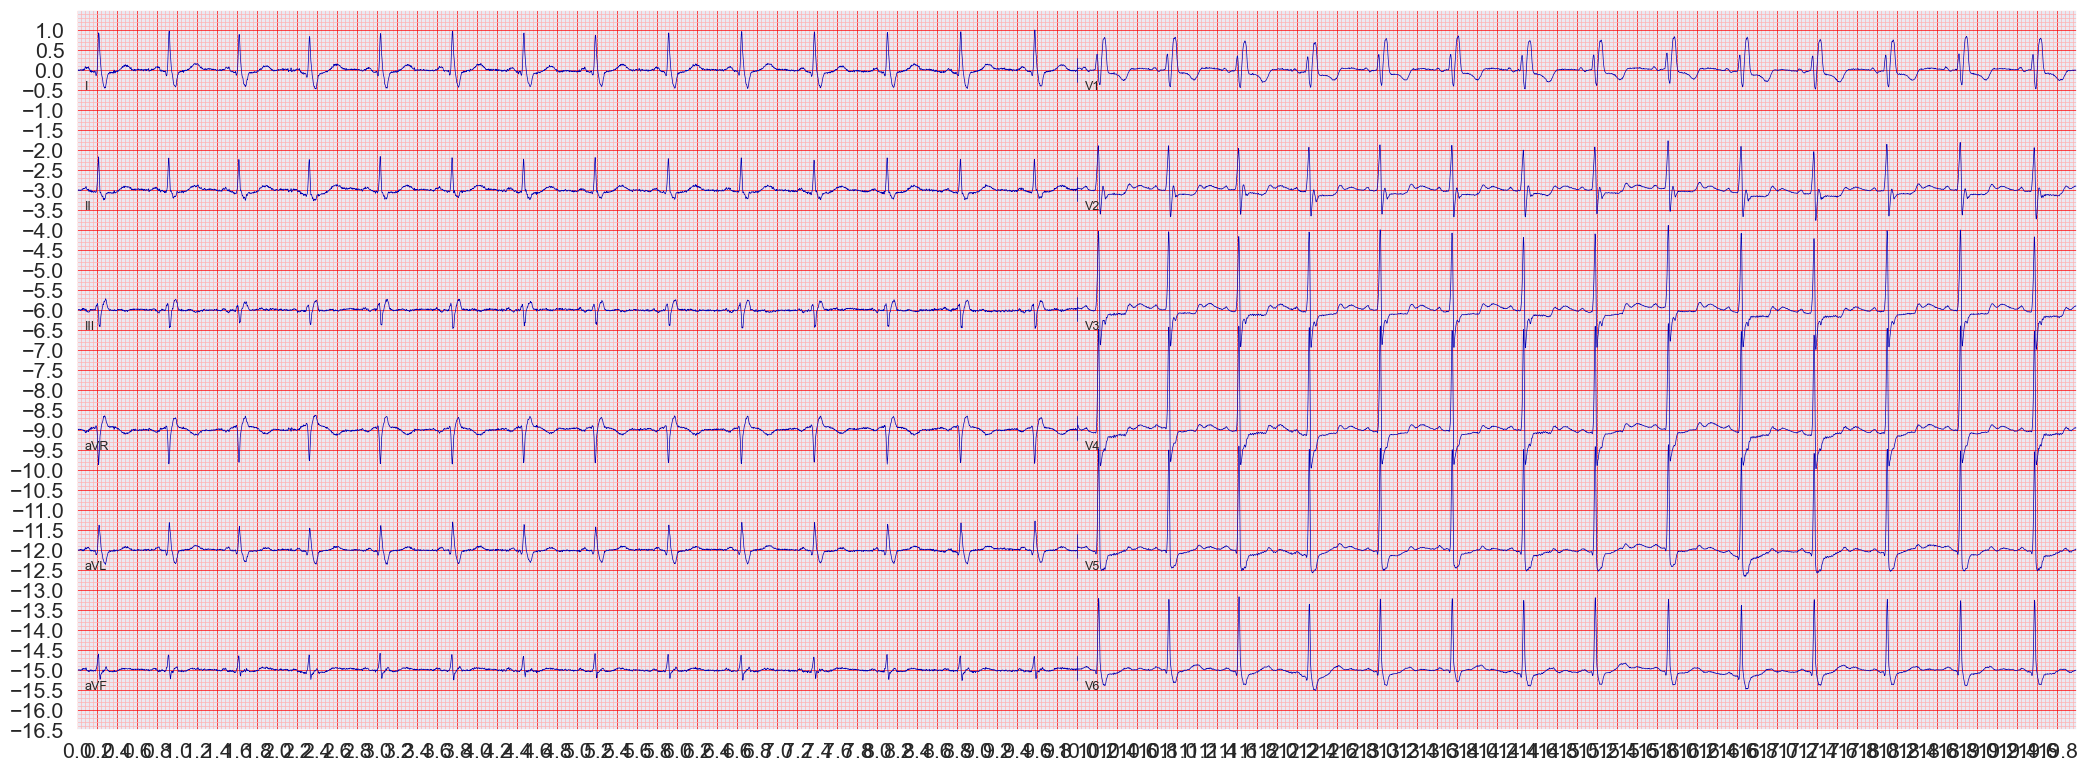

In [119]:
def plot_ecg(path):
    ecg_data = pc.load_challenge_data(path)
    ecg_plot.plot(ecg_data[0]/1000, sample_rate=500, title='')
    ecg_plot.show()

plot_ecg("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat") 

In [120]:
ecg_data = pc.load_challenge_data("data/china-12lead-ecg-challenge-database/Training_2/Q0948.mat")
ecg_data[0].shape

(12, 5000)

### Methods


#### Data
The training data in this study contains 43,101 Electrocariographic recordings from 4 different sources. 
1. Southeast University, China, including the data from the China Physiological Signal Challenge 2018 (2 datasets from this source)
2. St. Petersburg Institute of Cardiological Technics, St. Petersburg, Russia.
3. The Physikalisch Technische Bundesanstalt, Brunswick, Germany. (2 datasets from this source)
4. Georgia 12-Lead ECG Challenge Database, Emory University, Atlanta, Georgia, USA.

The data is given in the form of native Python waveform-database-format [WFDB](https://wfdb.readthedocs.io/en/latest/). The dataset contains two file types:


1.   Header files (.hea)
2.   Signal files (.mat)

We have 43,101 Signal file with a corresponding header file. Each file are named with a patient number starting with ***A0001*** and goes all the way up to ***A6877***


#### From the header file we have access to gender and age from each patient

In [121]:
SEX_RE = re.compile(r'(?i)#\s*sex\s*:\s*([A-Za-z?]+)')
AGE_RE = re.compile(r'(?i)#\s*age\s*:\s*([0-9]+|NaN|\?)')
DX_RE  = re.compile(r'(?i)#\s*dx\s*:\s*(.+)$')

def coerce_age(val):
    if val is None:
        return None
    v = val.strip()
    if v.lower() in {"nan", "?", ""}:
        return None
    try:
        return int(v)
    except ValueError:
        # sometimes age can be float-looking; try float -> int
        try:
            return int(float(v))
        except Exception:
            return None

def normalize_sex(val):
    if not val:
        return None
    v = val.strip().upper()
    # common encodings: M/F, Male/Female, U/?, etc.
    if v in {"M", "MALE"}:
        return "M"
    if v in {"F", "FEMALE"}:
        return "F"
    return None  # Unknown/other -> None (or return v if  want to keep)

def parse_header(hea_path: Path):
    sex = age = label = None
    signal_len = None
    fs = None

    with open(hea_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    if not lines:
        return sex, age, label, signal_len, fs

    # First line usually like: "<recname> <n_sig> <fs> <nsamp> <date> <time>"
    first = lines[0].strip()
    parts = first.split()
    if len(parts) >= 4:
        # parts[2] = fs, parts[3] = number of samples
        try:
            fs = int(float(parts[2]))
        except Exception:
            fs = None
        try:
            signal_len = int(parts[3])
        except Exception:
            signal_len = None

    # Now scan ALL lines for comment metadata
    for raw in lines:
        ln = raw.strip()
        if not ln.startswith("#"):
            continue

        m = SEX_RE.search(ln)
        if m and sex is None:
            sex = normalize_sex(m.group(1))

        m = AGE_RE.search(ln)
        if m and age is None:
            age = coerce_age(m.group(1))

        m = DX_RE.search(ln)
        if m and label is None:
            # Keep the raw label string; or split to list if  prefer
            label = m.group(1).strip()

    return sex, age, label, signal_len, fs

CSV_CACHE = r"notebooks\finalproject\ecg_index.csv"

def build_index(root, cache_path=CSV_CACHE):
    """
    Scan dataset and build a CSV index with ECG metadata.
    """
    rows = []
    root = Path(root)

    for mat_path in sorted(root.rglob("*.mat")):
        hea_path = mat_path.with_suffix(".hea")
        if not hea_path.exists():
            continue

        _, header_data = pc.load_challenge_data(str(mat_path))

        # mimic original parsing
        label  = header_data[15][5:-1]
        gender = header_data[14][6:-1]
        age    = header_data[13][6:-1]

        # try to grab fs and signal length from first line
        fs = siglen = duration = None
        try:
            parts = header_data[0].split()
            if len(parts) >= 4:
                fs = int(float(parts[2]))
                siglen = int(parts[3])
                duration = siglen / fs if (fs and siglen) else None
        except Exception:
            pass

        rows.append({
            "mat": str(mat_path),
            "hea": str(hea_path),
            "sex": gender,
            "age": age,
            "label": label,
            "signal_len": siglen,
            "fs": fs,
            "duration_sec": duration,
        })

    df = pd.DataFrame(rows)
    df.to_csv(cache_path, index=False)
    return df


In [122]:
REQUIRED_COLS = {"sex", "age", "label", "signal_len", "fs", "mat"}
CSV_CACHE = Path(r"notebooks\ecg_index.csv")

def _load_metadata(cache_path: Path):
    df = pd.read_csv(cache_path)
    missing = REQUIRED_COLS - set(df.columns)
    if missing:
        raise ValueError(f"Cache missing required columns: {missing}")
    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )

def _auto_detect_root():
    # Try a few common places for the dataset
    cwd = Path.cwd()
    candidates = [
        cwd,
        cwd / "data",
        cwd / "datasets",
        cwd.parent,
        cwd.parent / "data",
    ]
    for c in candidates:
        try:
            next(c.rglob("*.mat"))
            return c
        except StopIteration:
            continue
    return None

def get_or_build_ecg_metadata(root: str | Path = None,
                                cache_path: str | Path = CSV_CACHE,
                                force_rebuild: bool = False):
    """
    Return (sex, age, label, signal_len, fs, ecg_filenames).
    If cache exists/valid, read it. Otherwise, scan and build it.
    If root is None, attempt to auto-detect a dataset root.
    """
    cache_path = Path(cache_path)
    if not force_rebuild and cache_path.exists():
        return _load_metadata(cache_path)

    if root is None:
        root = _auto_detect_root()
        if root is None:
            raise RuntimeError(
                "Could not auto-detect dataset root (no .mat files found in common locations). "
                "Pass root=... explicitly."
            )
    root = Path(root)

    # Ensure cache dir exists
    cache_path.parent.mkdir(parents=True, exist_ok=True)

    # Build CSV via existing scanner
    df = build_index(root, cache_path=cache_path)

    # Normalize some fields
    if "age" in df.columns:
        df["age"] = df["age"].apply(coerce_age)
    if "sex" in df.columns:
        df["sex"] = df["sex"].apply(normalize_sex)
    for col in ["signal_len", "fs"]:
        if col not in df.columns:
            df[col] = None

    df.to_csv(cache_path, index=False)

    return (
        df["sex"].tolist(),
        df["age"].tolist(),
        df["label"].tolist(),
        df["signal_len"].tolist(),
        df["fs"].tolist(),
        df["mat"].tolist(),
    )


In [123]:
sex, age, labels, signal_len, fs, ecg_filenames = get_or_build_ecg_metadata(cache_path=CSV_CACHE)

#### From the figure under we can se that the signals varies, but most of the signals are around 5000 samples long

In [124]:
# Load CSV
df = pd.read_csv(CSV_CACHE)

def plot_signal_lengths(df, title):
    signal_count = df["signal_len"].value_counts()

    plt.figure(figsize=(20, 10))
    plt.title(title, fontsize=36)
    sns.barplot(x = signal_count[:10].index, y = signal_count[:10].values)
    plt.xlabel("Signal length (samples)", fontsize=18)
    plt.ylabel("Count", fontsize=18)
    plt.show()

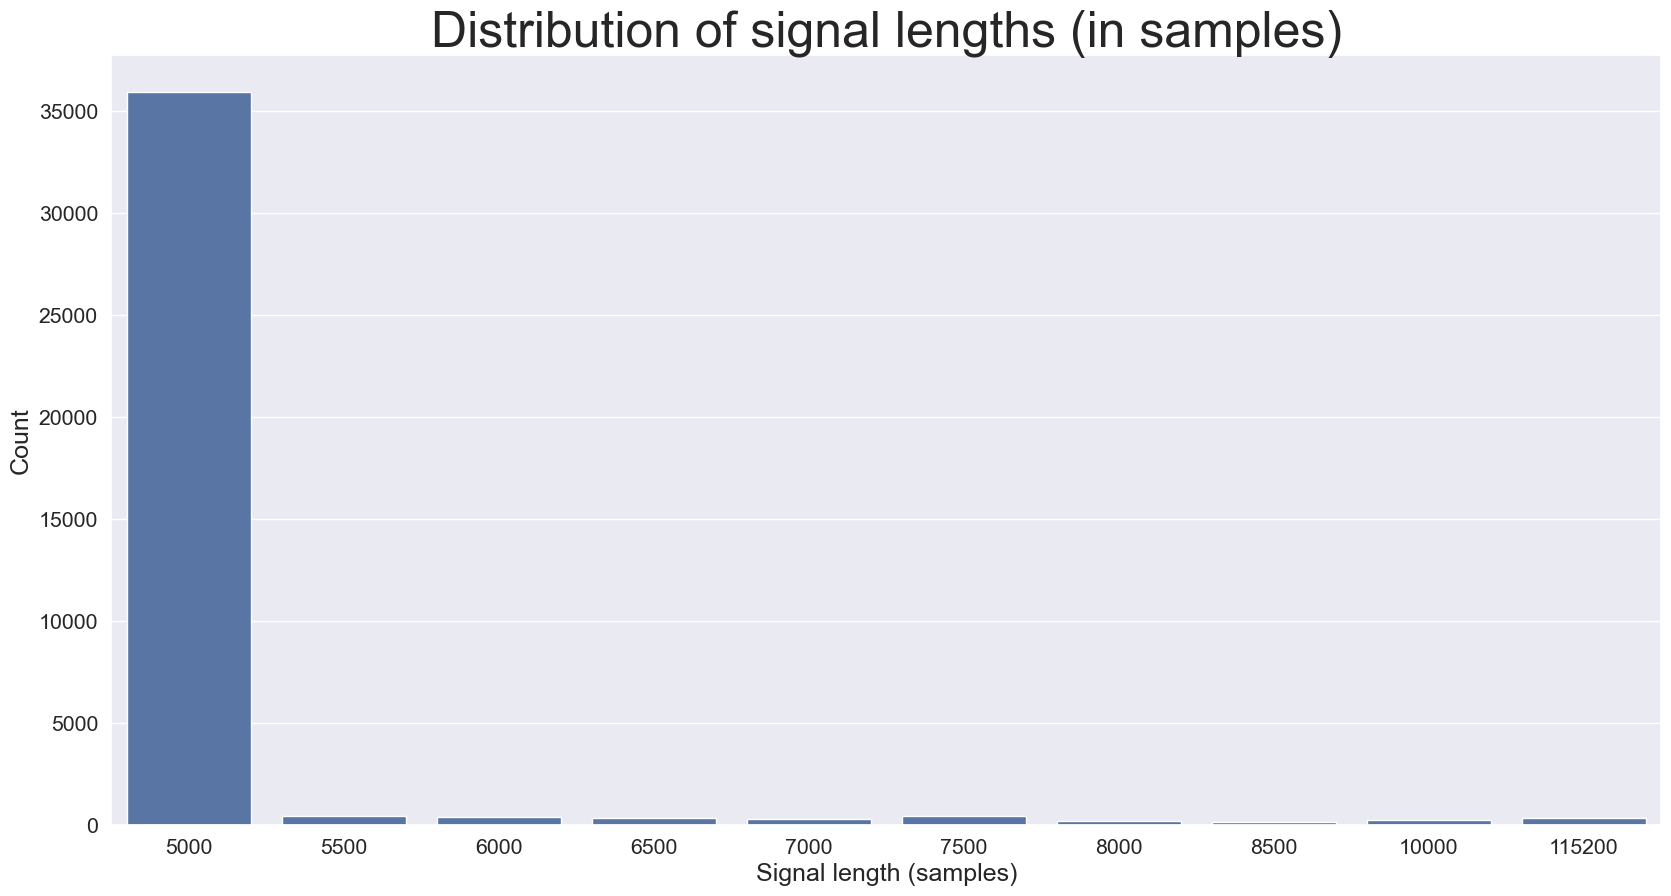

In [125]:
plot_signal_lengths(df, "Distribution of signal lengths (in samples)")

#### All diagnoses are encoded with SNOMED-CT codes. We need a CSV-file to decode them:

In [126]:
SNOMED_scored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_scored.csv", sep=";")
SNOMED_unscored = pd.read_csv("data/physionet-snomed-mappings/SNOMED_mappings_unscored.csv", sep=";")

df_labels = pc.make_undefined_class(labels, SNOMED_unscored)

In [127]:
print(df_labels)

                                                       0
0                              undefined class,427084000
1                                        undefined class
2                        undefined class,undefined class
3                        undefined class,undefined class
4                                        undefined class
...                                                  ...
43096    undefined class,undefined class,undefined class
43097  undefined class,undefined class,427084000,unde...
43098  undefined class,undefined class,426627000,6359...
43099  undefined class,427084000,undefined class,unde...
43100  undefined class,426627000,undefined class,unde...

[43101 rows x 1 columns]


#### To be able to feed the labels to a Neural Network we need to OneHot encode the labels

In [128]:
y , snomed_classes = pc.onehot_encode(df_labels)

The classes we will look at are encoded as SNOMED CT codes:
['10370003' '111975006' '164889003' '164890007' '164909002' '164917005'
 '164934002' '164947007' '17338001' '251146004' '270492004' '284470004'
 '39732003' '426177001' '426627000' '426783006' '427084000' '427172004'
 '427393009' '445118002' '47665007' '59118001' '59931005' '63593006'
 '698252002' '713426002' '713427006' 'undefined class']
classes: 27


In [129]:
y.shape

(43101, 27)

In [130]:
snomed_abbr = []
for j in range(len(snomed_classes)):
    for i in range(len(SNOMED_scored.iloc[:,1])):
        if (str(SNOMED_scored.iloc[:,1][i]) == snomed_classes[j]):
            snomed_abbr.append(SNOMED_scored.iloc[:,2][i])
            
snomed_abbr = np.asarray(snomed_abbr)

#### The distribution of diagnoses accross the dataset
In the figure under we can see the same SNOMED CT codes decoded into human readable diagnoses on the X-axis. On the Y-axis we have the number of the given diagnoses in the dataset

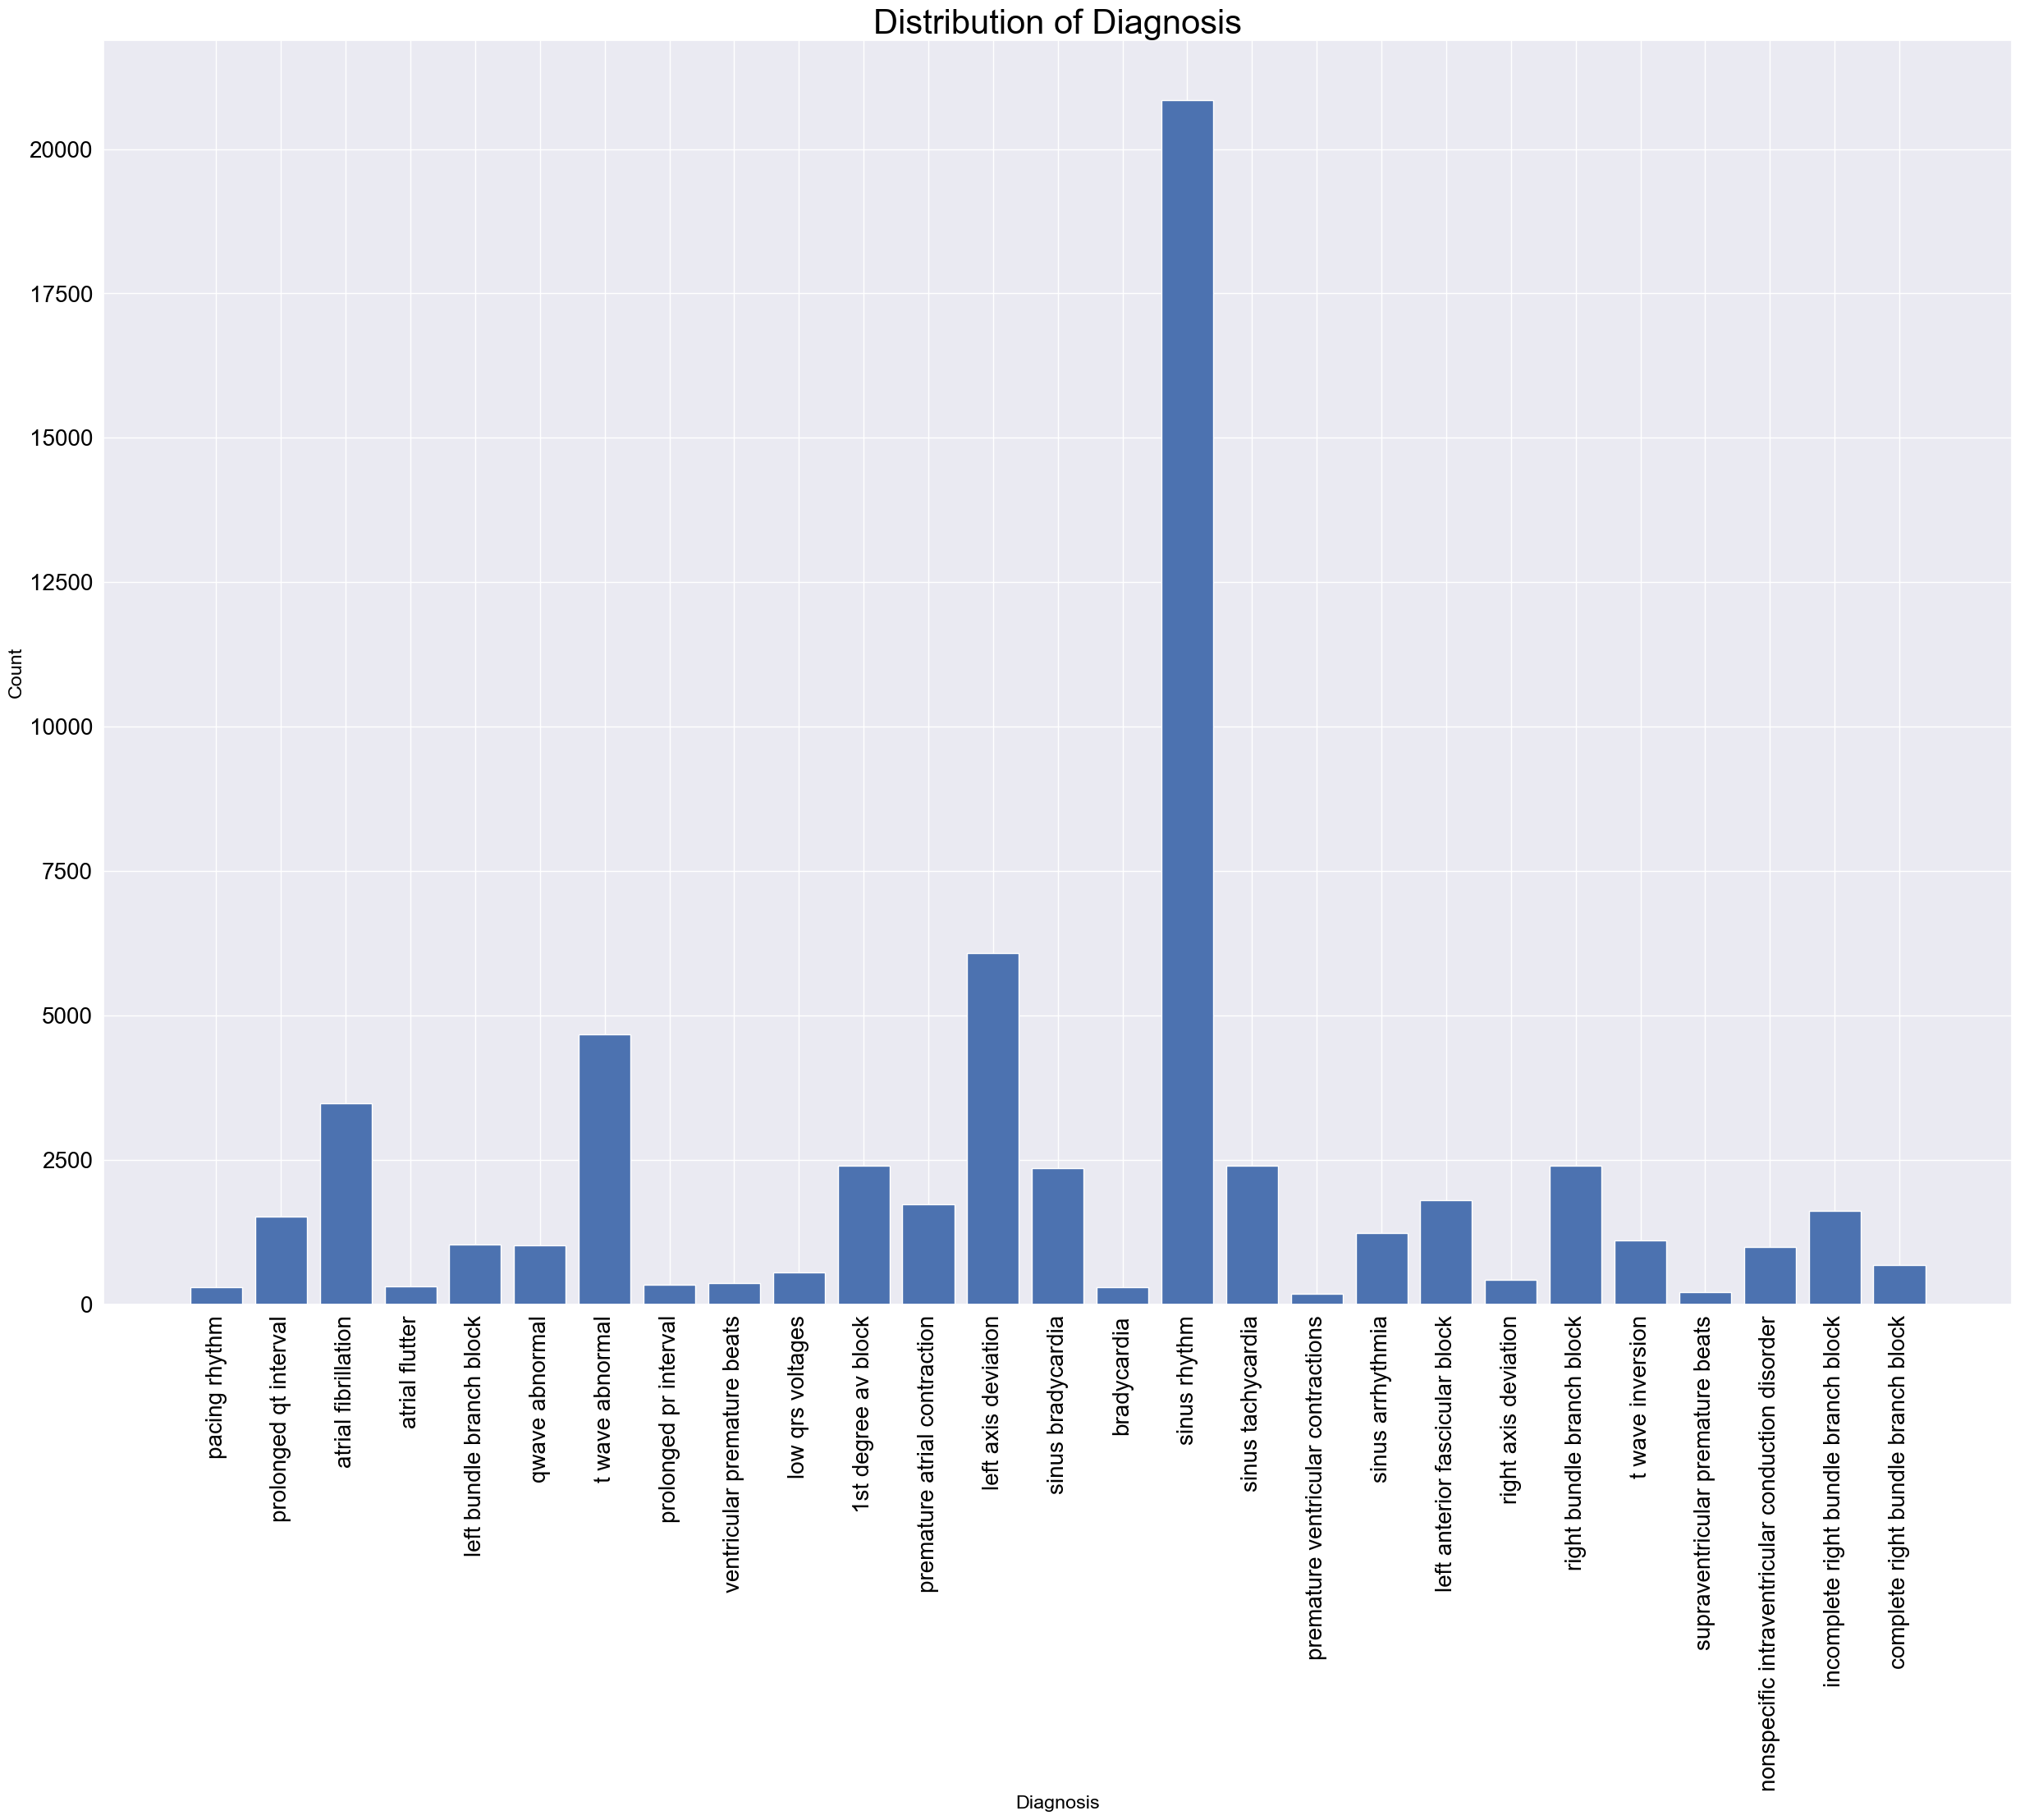

In [131]:
pc.plot_classes(snomed_classes, SNOMED_scored,y)

#### Since this is a multiclass multi-label classification there will be a lot of different combinations of the 27 diagnoses in this study

In [132]:
y_all_comb = pc.get_labels_for_all_combinations(y)
print("Total number of unique combinations of diagnosis: {}".format(len(np.unique(y_all_comb))))

Total number of unique combinations of diagnosis: 1414


#### We will split the data using a 10-fold split with Shuffle=True and random_seed = 42. 
The distribution of Training and Val data in each fold is now:
(in this study we only use the first fold for hold out validation)

In [133]:
folds = pc.split_data(labels, y_all_comb)

Training split: 38790
Validation split: 4311


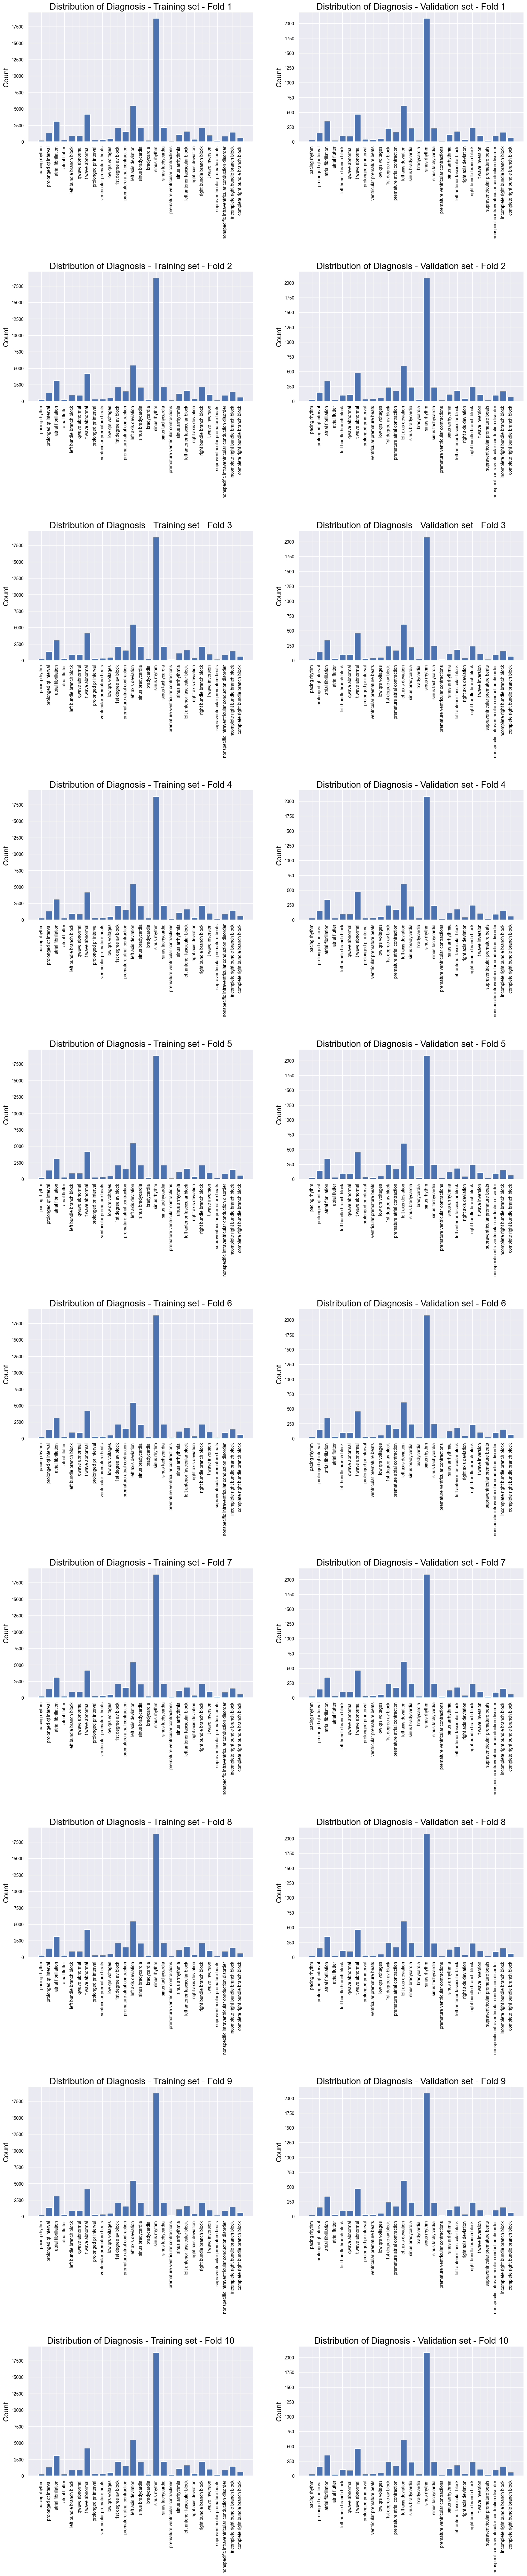

In [134]:
pc.plot_all_folds(folds,y,snomed_classes)

#### Make Batch generators
To feed the Neural Network with a dataset that is too large for our RAM set we need a batch generator to get data into the RAM in batches.
We start by making a "order array" so we can shuffle the order of the data during the training process

In [135]:
order_array = folds[0][0]

In [136]:
def shuffle_batch_generator_demo(batch_size, gen_x,gen_y, gen_z): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    batch_demo_data = np.zeros((batch_size,2))
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            batch_demo_data[i] = next(gen_z)

        X_combined = [batch_features, batch_demo_data]
        yield X_combined, batch_labels
        
def shuffle_batch_generator(batch_size, gen_x,gen_y): 
    np.random.shuffle(order_array)
    batch_features = np.zeros((batch_size,5000, 12))
    batch_labels = np.zeros((batch_size,snomed_classes.shape[0])) #drop undef class
    while True:
        for i in range(batch_size):

            batch_features[i] = next(gen_x)
            batch_labels[i] = next(gen_y)
            
        yield batch_features, batch_labels

def generate_y_shuffle(y_train):
    while True:
        for i in order_array:
            y_shuffled = y_train[i]
            yield y_shuffled

def generate_X_shuffle(X_train):
    while True:
        for i in order_array:
                #if filepath.endswith(".mat"):
                    data, header_data = pc.load_challenge_data(X_train[i])
                    X_train_new = pad_sequences(data, maxlen=5000, truncating='post',padding="post")
                    X_train_new = X_train_new.reshape(5000,12)
                    yield X_train_new

def generate_z_shuffle(age_train, gender_train):
    while True:
        for i in order_array:
            gen_age = age_train[i]
            gen_gender = gender_train[i]
            z_train = [gen_age , gen_gender]
            yield z_train

#### Imbalanced data
To compensate for the imbalaced data we calculate a weight for each label. The weight decides how much the Neural Network will learn from the different data labels

In [137]:
new_weights=pc.calculating_class_weights(y)

In [138]:
keys = np.arange(0,27,1)
weight_dictionary = dict(zip(keys, new_weights.T[1]))
weight_dictionary

{0: 72.0752508361204,
 1: 14.243555849306015,
 2: 6.201582733812949,
 3: 68.63216560509554,
 4: 20.701729106628243,
 5: 21.273938795656466,
 6: 4.611705542478066,
 7: 63.383823529411764,
 8: 59.04246575342466,
 9: 38.759892086330936,
 10: 9.00187969924812,
 11: 12.464141122035858,
 12: 3.5409957279000985,
 13: 9.13543874523103,
 14: 74.828125,
 15: 1.0337954523649622,
 16: 8.971898417985013,
 17: 114.63031914893617,
 18: 17.379435483870967,
 19: 11.932724252491694,
 20: 50.469555035128806,
 21: 8.971898417985013,
 22: 19.379946043165468,
 23: 100.23488372093023,
 24: 21.615346038114343,
 25: 13.37709497206704,
 26: 31.552708638360176}

#### Learning rate reduction
To controll the learning rate we use learning rate reduction and early stopping to prevent overfitting

In [139]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_AUC', factor=0.1, patience=1, verbose=1, mode='max',
    min_delta=0.0001, cooldown=0, min_lr=0
)

early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_AUC', mode='max', verbose=1, patience=2)

#### To find the optimal threshold we will use Downhill simplex method

In [140]:
def thr_chall_metrics(thr, label, output_prob):
    return -pc.compute_challenge_metric_for_opt(label, np.array(output_prob>thr))

### Results

#### Residual Neural Network

In [27]:
model = pc.residual_network_1d()

load a pre-trained model - trained parameters (weights & biases)

In [141]:
model.load_weights("data/physionet-challenge-models/resnet_model.h5")

#### Visualizing the Model

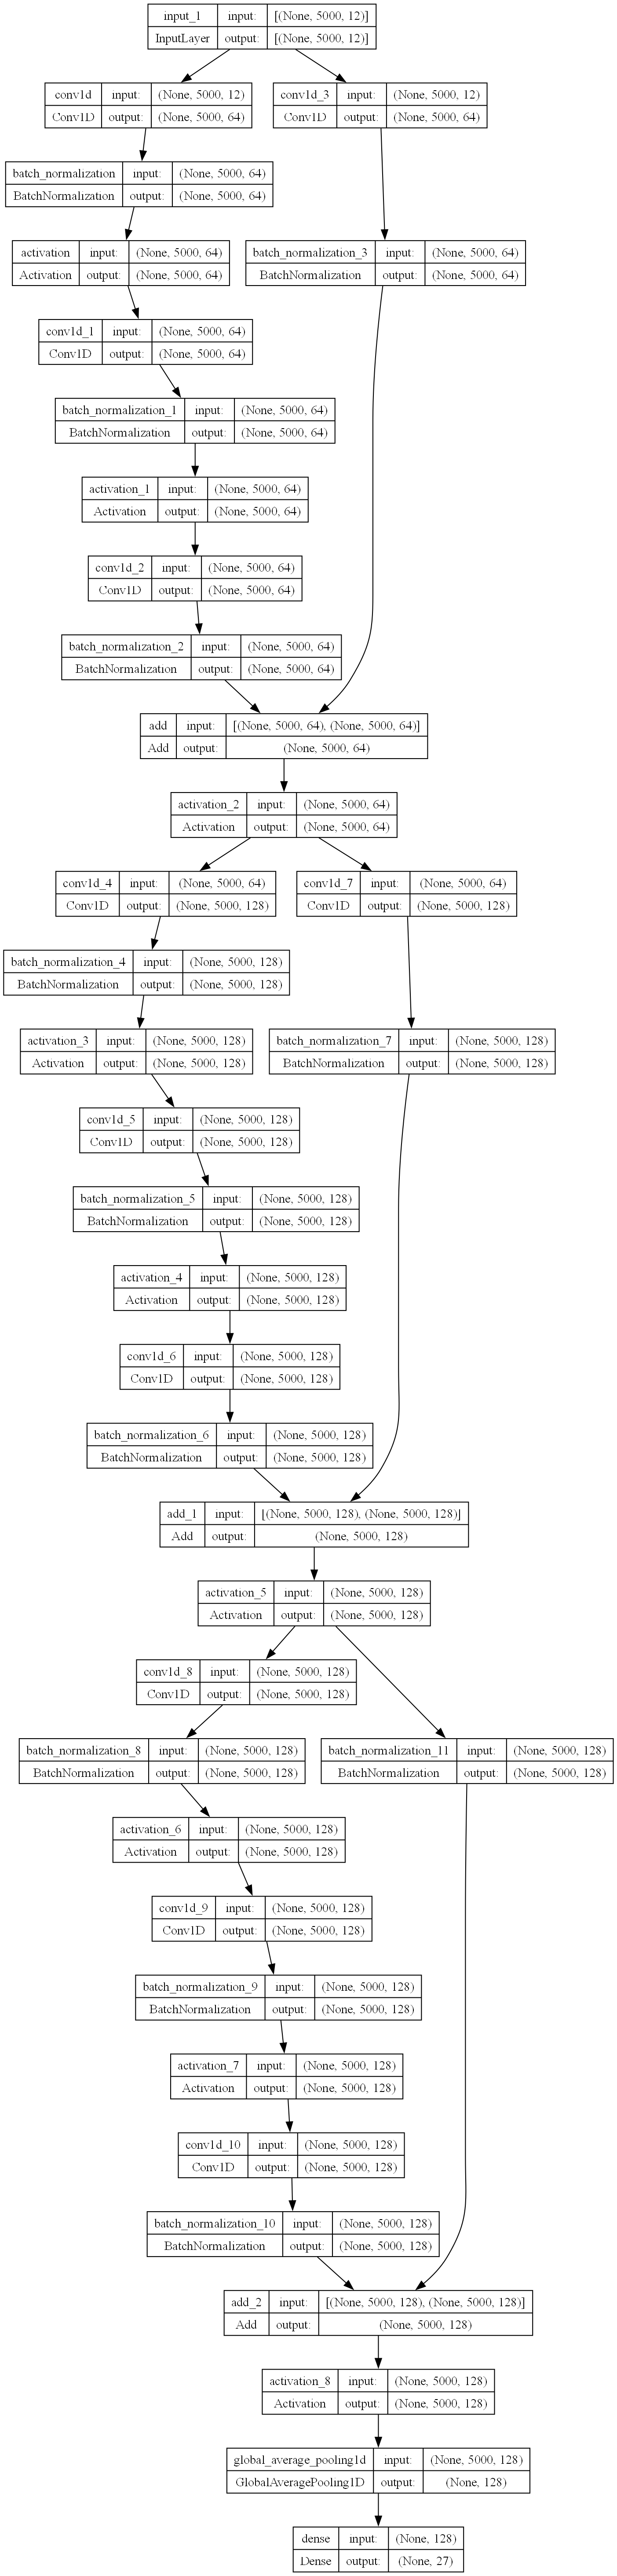

In [142]:
plot_model(
    model,
    to_file="resnet1d.png",
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",   # vertical; use "LR" for left→right
    dpi=150
)

In [30]:
ecg_filenames = np.asarray(ecg_filenames, dtype=object)
y_pred = model.predict(x = pc.generate_validation_data(ecg_filenames, y, folds[0][1])[0])

135/135 [==============================] - 92s 681ms/step


In [ ]:
# ------------- registry of model builders (ECG-only inputs) -------------
MODEL_ZOO = {
    "resnet": pc.residual_network_1d,
    "fcn": pc.FCN,
    "encoder": pc.encoder_model,
    "fcn_encoder": pc.FCN_Encoder,
}


In [149]:
def finetune_model(build_model_fn,
                   X_train, y_train, X_val, y_val,
                   ckpt_path=None,
                   freeze_until=None,         # e.g. "add" or "global_average_pooling1d"
                   warmup_epochs=5,
                   finetune_epochs=20,
                   warmup_lr=1e-3,
                   finetune_lr=5e-4,
                   batch_size=64):
    # 1) build
    model = build_model_fn()

    # 2) optional: load weights
    if ckpt_path and os.path.exists(ckpt_path):
        model.load_weights(ckpt_path)

    # 3) optionally freeze early layers
    if freeze_until is not None:
        freeze = True
        for layer in model.layers:
            layer.trainable = not freeze
            if layer.name == freeze_until:
                freeze = False

    # 4) warm-up (head only or few trainable layers)
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(warmup_lr),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy'),
            tf.keras.metrics.Recall(name='Recall'),
            tf.keras.metrics.Precision(name='Precision'),
            tf.keras.metrics.AUC(curve="ROC", multi_label=True, name="AUC"),
        ],
    )

    cbs = [
        tf.keras.callbacks.EarlyStopping(monitor="val_AUC", mode="max", patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_AUC", mode="max", factor=0.5, patience=2, min_lr=1e-6),
    ]

    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=warmup_epochs,
              batch_size=batch_size,
              callbacks=cbs,
              verbose=1)

    # 5) unfreeze all + fine-tune with lower LR
    for layer in model.layers:
        layer.trainable = True

    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(finetune_lr),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy'),
            tf.keras.metrics.Recall(name='Recall'),
            tf.keras.metrics.Precision(name='Precision'),
            tf.keras.metrics.AUC(curve="ROC", multi_label=True, name="AUC"),
        ],
    )

    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=finetune_epochs,
              batch_size=batch_size,
              callbacks=cbs,
              verbose=1)

    return model


In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

def per_class_thresholds(y_true, y_score):
    C = y_true.shape[1]
    th = np.zeros(C, dtype=float)
    for c in range(C):
        p, r, t = precision_recall_curve(y_true[:, c].astype(int), y_score[:, c])
        f1 = 2*p*r/(p+r+1e-12)
        i = int(np.nanargmax(f1))
        th[c] = (t[max(i-1,0)] if len(t) else 0.5)
    return th

def binarize_by_thresholds(y_score, th):
    return (y_score >= th[None, :]).astype(int)

def get_data_for_indices(ecg_filenames, y, idx):
    # Your helper returns (X, y) from given indices
    X, y_sub = pc.generate_validation_data(np.asarray(ecg_filenames), y, np.asarray(idx))
    return X, y_sub

def train_eval_one(model_name, train_idx, val_idx,
                   ecg_filenames, y,
                   epochs=15, batch=64, lr=1e-3,
                   fine_tune=False, ckpt=None):
    X_train, y_train = get_data_for_indices(ecg_filenames, y, train_idx)
    X_val,   y_val   = get_data_for_indices(ecg_filenames, y, val_idx)

    build_fn = MODEL_ZOO[model_name]

    if fine_tune:
        model = finetune_model(build_fn, X_train, y_train, X_val, y_val,
                               ckpt_path=ckpt, freeze_until=None,
                               warmup_epochs=max(3, epochs//5),
                               finetune_epochs=max(10, epochs),
                               warmup_lr=lr, finetune_lr=lr*0.5, batch_size=batch)
    else:
        model = build_fn()
        model.compile(
            loss=tf.keras.losses.BinaryCrossentropy(),
            optimizer=tf.keras.optimizers.Adam(lr),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy'),
                tf.keras.metrics.Recall(name='Recall'),
                tf.keras.metrics.Precision(name='Precision'),
                tf.keras.metrics.AUC(curve="ROC", multi_label=True, name="AUC"),
            ],
        )
        cbs = [
            tf.keras.callbacks.EarlyStopping(monitor="val_AUC", mode="max", patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_AUC", mode="max", factor=0.5, patience=2, min_lr=1e-6),
        ]
        model.fit(X_train, y_train,
                  validation_data=(X_val, y_val),
                  epochs=epochs,
                  batch_size=batch,
                  callbacks=cbs,
                  verbose=1)

    # predictions + thresholds
    y_val_score = model.predict(X_val, verbose=0)
    th = per_class_thresholds(y_val, y_val_score)
    y_val_bin = binarize_by_thresholds(y_val_score, th)

    # metrics
    res = {}
    eval_out = model.evaluate(X_val, y_val, verbose=0, return_dict=True)
    res.update({f"{model_name}/{k}": float(v) for k, v in eval_out.items()})

    # challenge metric (your function expects (labels, outputs) as 0/1)
    ch = pc.compute_challenge_metric_for_opt(y_val.astype(int), y_val_bin.astype(int))
    res[f"{model_name}/challenge_score"] = float(ch)

    return res, (y_val, y_val_score, th, y_val_bin)

def benchmark_models(model_names, ecg_filenames, y, folds, fold_id=0,
                        epochs=15, batch=64, lr=1e-3, fine_tune=False, ckpt_map=None,
                        plot_confmats=True):
    train_idx, val_idx = folds[fold_id]
    all_results = []
    per_model_artifacts = {}

    for name in model_names:
        ckpt = None if ckpt_map is None else ckpt_map.get(name)
        res, arts = train_eval_one(name, train_idx, val_idx, ecg_filenames, y,
                                    epochs=epochs, batch=batch, lr=lr,
                                    fine_tune=fine_tune, ckpt=ckpt)
        all_results.append(res)
        per_model_artifacts[name] = arts

        # confusion matrix (normalized) using your helper
        if plot_confmats:
            y_val, y_val_score, th, y_val_bin = arts
            # single global threshold if you prefer:
            # threshold = 0.3
            # plot_normalized_conf_matrix(y_val_score, ecg_filenames, y, val_idx, threshold, snomedclasses, snomedabbr)
            # per-class thresholds:
            conf = pc.compute_modified_confusion_matrix(y_val.astype(int), y_val_bin.astype(int))
            conf = np.nan_to_num(conf)
            norm = conf / (conf.sum(axis=1, keepdims=True) + 1e-12)
            plt.figure(figsize=(10,8))
            sns.heatmap(norm, cmap="rocket_r", square=True, cbar=False)
            plt.title(f"Normalized Confusion (val) — {name}")
            plt.xlabel("Predicted"); plt.ylabel("Actual")
            plt.show()

    # results table
    df = pd.DataFrame(all_results)
    return df, per_model_artifacts


In [151]:
# 1) Build labels etc. (you likely already have this)
# gender, age, labels, ecg_filenames = import_key_data(DATA_ROOT)
# df_labels = make_undefined_class(labels, df_unscored)   # if you use unscored merging
# y, snomedclasses = onehot_encode(df_labels)

y_all_combo = pc.get_labels_for_all_combinations(y)
folds = list(pc.StratifiedKFold(n_splits=5, shuffle=True, random_state=42).split(y, y_all_combo))

# 2) Compare a few models on fold 0
model_list = ["resnet", "fcn", "encoder"]
results_df, artifacts = benchmark_models(
    model_list,
    ecg_filenames, y,
    folds=folds, fold_id=0,
    epochs=15, batch=64, lr=1e-3,
    fine_tune=False, ckpt_map=None,       # set fine_tune=True + ckpt_map if you have checkpoints
    plot_confmats=True
)

print(results_df.T)   # nice quick view


Epoch 1/15
193/539 [=========>....................] - ETA: 50:12 - loss: 0.1668 - accuracy: 0.9484 - Recall: 0.2520 - Precision: 0.5046 - AUC: 0.6695

KeyboardInterrupt: 

In [31]:
init_thresholds = np.arange(0, 1, 0.05)

In [32]:
all_scores = pc.iterate_threshold(y_pred, ecg_filenames, y, folds[0][1])

0.1516625863156977
0.3257728585224567
0.34907885319229215
0.28868950738443655
0.181260365067383
0.07488523992867367
-0.030592151530913974
-0.13422631975369734
-0.2242114341113018
-0.3122581976641526
-0.3953465808086114
-0.47448587178946944
-0.5439621181557601
-0.6015332151710997
-0.6651141368699174
-0.7092221508645785
-0.7470735743049693
-0.7760926050516812
-0.8006819928304572
-0.8173020165059404


In [33]:
new_best_thr = optimize.fmin(thr_chall_metrics, 
                                args = (pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1], y_pred), 
                                x0 = init_thresholds[all_scores.argmax()] * np.ones(27))

Optimization terminated successfully.
         Current function value: -0.380630
         Iterations: 302
         Function evaluations: 579


In [34]:
print(pc.compute_challenge_metric_for_opt(pc.generate_validation_data(ecg_filenames,y,folds[0][1])[1],(y_pred>new_best_thr)*1))

0.38063028434382484


Make conf.matrix

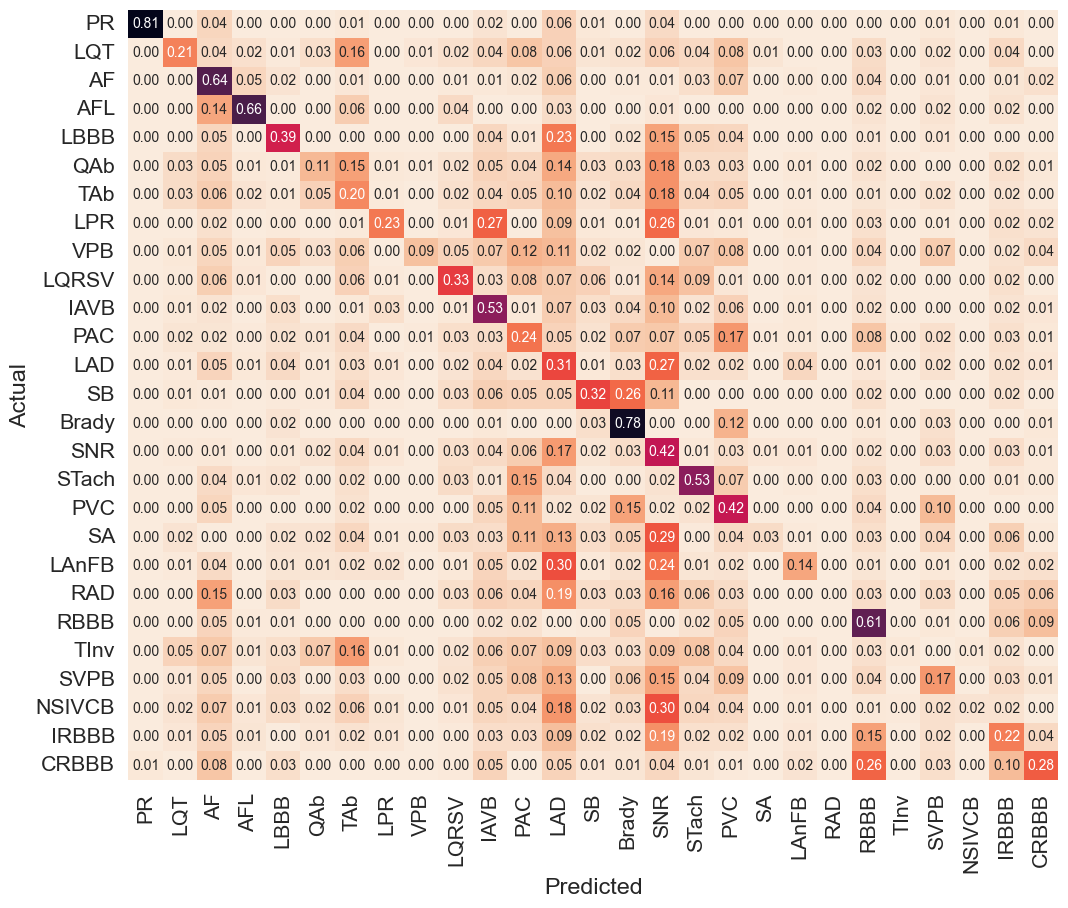

In [35]:
pc.plot_normalized_conf_matrix(y_pred, ecg_filenames, y, folds[0][1], new_best_thr, snomed_classes, snomed_abbr)
plt.savefig("confusion_matrix_resnet.png", dpi=100)

In [36]:
test_aa = pc.generate_validation_data(ecg_filenames,y,folds[0][1])[0]
print(test_aa.shape)

(4311, 5000, 12)


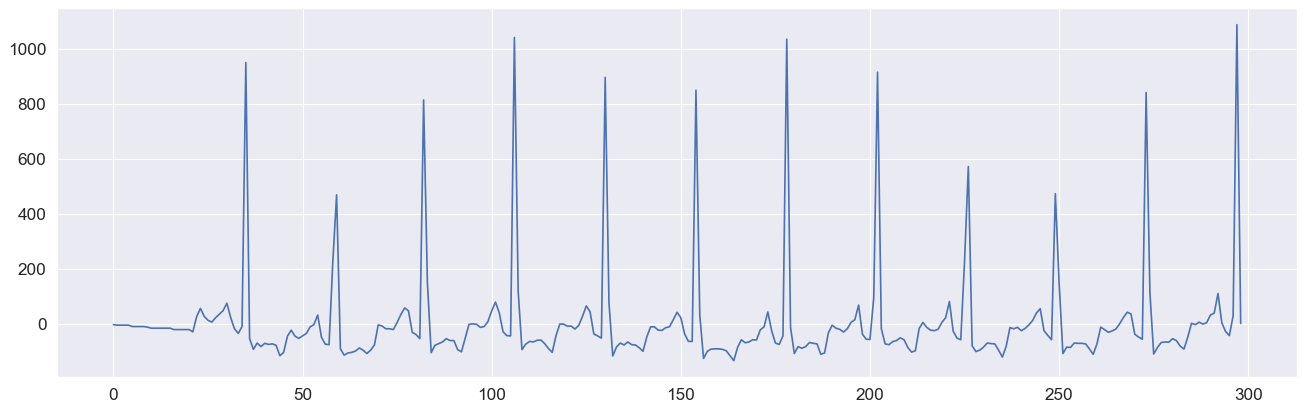

In [37]:
figure(figsize=(20, 6), dpi=80)
plt.plot(test_aa[0,1:300,0])

In [38]:
y_pred.shape

(4311, 27)

In [39]:
test_aa[:2,:,:].shape

(2, 5000, 12)

In [40]:
sample = np.array(test_aa[0:10]).copy()
sample.shape

(10, 5000, 12)

In [41]:
ecg_multilabel_eval_path = r"C:\Users\nares\Documents\cvd-early-detection-ecg-uhull\notebooks\ecg_multilabel_eval.py"
sys.path.append(os.path.dirname(ecg_multilabel_eval_path))
from ecg_multilabel_eval import compute_per_class_metrics, plot_roc_for_top_k

In [42]:
# Use your existing predictions for the validation fold:
val_idx = folds[0][1]                 # validation indices for fold 0
y_val_true = y[val_idx]               # (N_val, C), binary
y_val_prob = y_pred                   # (N_val, C) from your model.predict(...)
class_names = list(snomed_classes)    # length C

per_class = compute_per_class_metrics(y_val_true, y_val_prob, class_names)
print("micro AUROC:", per_class.attrs["micro_auroc"])
print("macro AUROC:", per_class.attrs["macro_auroc"])
per_class.sort_values("prevalence", ascending=False).head(15)

micro AUROC: 0.9186329108151453
macro AUROC: 0.886997975650601


,class_name,prevalence,accuracy,sensitivity,specificity,auroc,auprc,threshold,tp,fp,tn,fn
15,sinus rhythm,0.484110,0.874507,0.849545,0.897932,0.942678,0.942270,0.095973,1773,227,1997,314
12,left axis deviation,0.141730,0.812341,0.754501,0.821892,0.858552,0.579013,0.047072,461,659,3041,150
6,t wave abnormal,0.108096,0.727673,0.718884,0.728739,0.795437,0.375049,0.035246,335,1043,2802,131
2,atrial fibrillation,0.082116,0.950592,0.920904,0.953247,0.975214,0.862946,0.080037,326,185,3772,28
21,right bundle branch block,0.054744,0.892136,0.927966,0.890061,0.963879,0.767728,0.082023,219,448,3627,17
13,sinus bradycardia,0.054512,0.917421,0.923404,0.917076,0.972311,0.732693,0.028649,217,338,3738,18
16,sinus tachycardia,0.054280,0.943169,0.948718,0.942850,0.973496,0.826448,0.046928,222,233,3844,12
10,1st degree av block,0.053352,0.926699,0.904348,0.927959,0.969484,0.729842,0.094258,208,294,3787,22
19,left anterior fascicular block,0.041290,0.849223,0.898876,0.847084,0.937118,0.540265,0.014417,160,632,3501,18
11,premature atrial contraction,0.039434,0.671770,0.694118,0.670852,0.710665,0.122942,0.087229,118,1363,2778,52


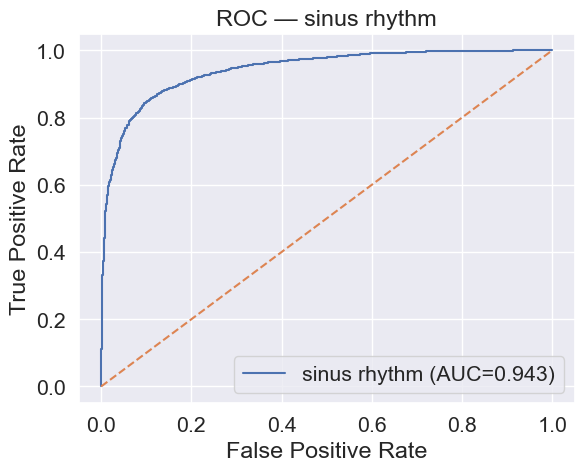

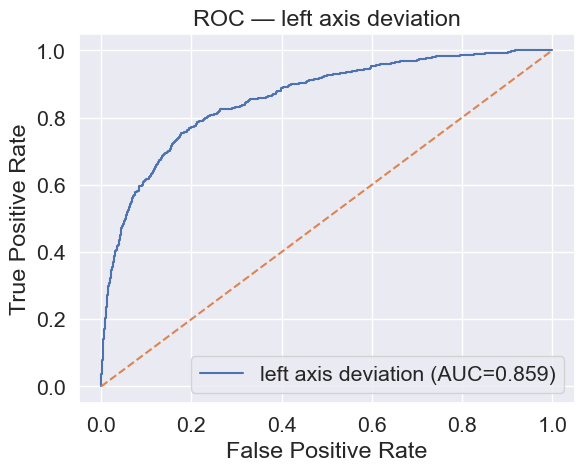

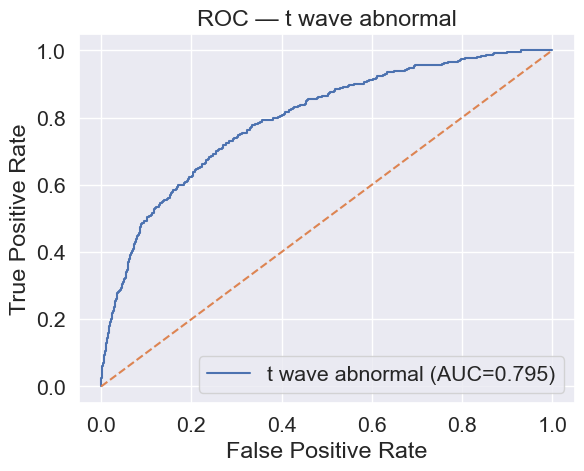

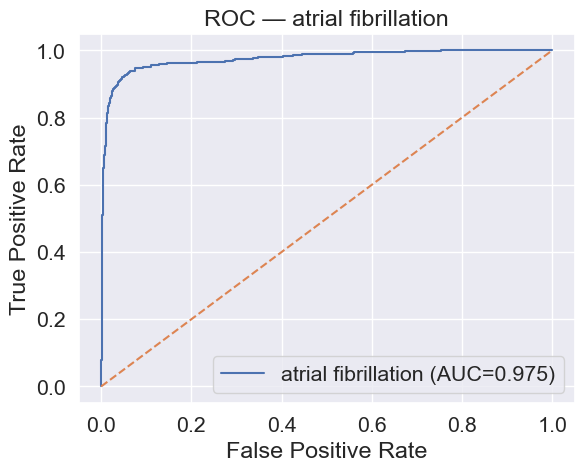

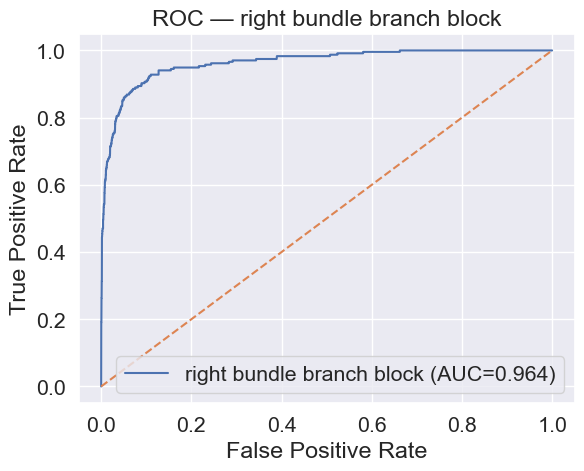

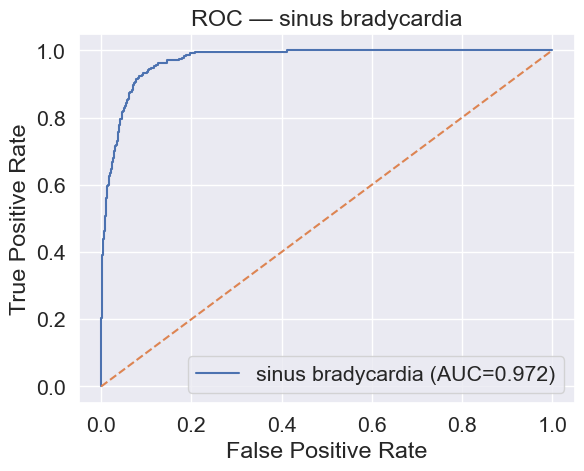

In [43]:
plot_roc_for_top_k(y_val_true, y_val_prob, class_names, k=6)

In [44]:
meta = pd.read_csv(CSV_CACHE)

# Make a per-record DF for the current validation fold:
from ecg_multilabel_eval import make_eval_dataframe_for_fold

df_val = make_eval_dataframe_for_fold(
    val_idx=val_idx,
    ecg_filenames=ecg_filenames,
    y_true=y,
    y_prob=y_pred,
    class_names=class_names,
    meta_df=meta,             # optional; merges on "filename"
    file_col=ecg_filenames      # change if your column name differs
)
df_val.head()

,filename,y_pacing rhythm,p_pacing rhythm,y_prolonged qt interval,p_prolonged qt interval,y_atrial fibrillation,p_atrial fibrillation,y_atrial flutter,p_atrial flutter,y_left bundle branch block,...,y_complete right bundle branch block,p_complete right bundle branch block,mat,hea,sex,age,label,signal_len,fs,duration_sec
0,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.000135,0,0.006890,0,0.004619,0,0.001612,0,...,0,0.000639,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,F,53.0,"428750005,427084000",20846,500,41.692
1,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.000051,0,0.001068,0,0.006033,0,0.001909,0,...,0,0.007396,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,57.0,"164867002,426627000",5000,500,10.000
2,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.000186,0,0.035446,0,0.001793,0,0.004760,0,...,0,0.003300,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,F,63.0,164867002,28376,500,56.752
3,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.000511,0,0.001053,0,0.004573,0,0.000955,0,...,0,0.005552,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,68.0,"284470004,428750005",17000,500,34.000
4,C:\Users\nares\Documents\cvd-early-detection-e...,0,0.000861,0,0.000404,0,0.019923,0,0.004382,0,...,0,0.001579,C:\Users\nares\Documents\cvd-early-detection-e...,C:\Users\nares\Documents\cvd-early-detection-e...,M,87.0,"27885002,164865005",11500,500,23.000


In [45]:
from ecg_multilabel_eval import subgroup_table_binary

target = "atrial fibrillation"

df_val["age_band"] = pd.cut(df_val["age"], bins=[0,40,60,80,200], labels=["<=40","41-60","61-80",">80"])
df_val["len_band"] = pd.qcut(df_val["signal_len"], q=4, duplicates="drop")

tab_sex = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="sex")
tab_age = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="age_band")
tab_len = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="len_band")
tab_fs  = subgroup_table_binary(df_val, label_col=f"y_{target}", prob_col=f"p_{target}", group_col="fs")

In [46]:
tab_len

,len_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,"(2499.999, 5000.0]",3606,0.075707,0.950361,0.915751,0.953195,0.973703,0.854550,250,156,3177,23
1,"(5000.0, 462600.0]",705,0.114894,0.951773,0.938272,0.953526,0.978929,0.886682,76,29,595,5


In [47]:
tab_age

,age_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
2,61-80,1947,0.106317,0.937339,0.917874,0.939655,0.974826,0.907817,190,105,1635,17
1,41-60,1306,0.035988,0.973201,0.851064,0.977760,0.961452,0.830623,40,28,1231,7
0,<=40,583,0.008576,0.967410,1.000000,0.967128,0.999654,0.966667,5,19,559,0
3,>80,457,0.199125,0.921225,0.956044,0.912568,0.963340,0.797266,87,32,334,4


In [48]:
tab_len

,len_band,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,"(2499.999, 5000.0]",3606,0.075707,0.950361,0.915751,0.953195,0.973703,0.854550,250,156,3177,23
1,"(5000.0, 462600.0]",705,0.114894,0.951773,0.938272,0.953526,0.978929,0.886682,76,29,595,5


In [49]:
tab_fs

,fs,n,prevalence,Accuracy,Sensitivity,Specificity,AUROC,AUPRC,TP,FP,TN,FN
0,500,4252,0.08302,0.950376,0.92068,0.953065,0.975506,0.864156,325,183,3716,28
1,1000,48,0.00000,0.958333,0.00000,0.958333,NaN,0.000000,0,2,46,0


In [50]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve
import plotly.graph_objects as go

def youden_threshold(y_true, y_prob):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    if y_true.max() == y_true.min():
        return 0.5
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def plotly_confusion_matrix(cm, title="Confusion Matrix", normalize=None):
    """
    cm: 2x2 ndarray (TN FP / FN TP with labels=[0,1])
    normalize: None | 'true' (row-wise) | 'pred' (col-wise) | 'all'
    """
    cm = np.asarray(cm, dtype=float)

    def pct_text(arr):
        return np.char.add(np.round(arr * 100.0, 1).astype(str), '%')

    # Normalize safely (avoid NaNs on zero-division)
    if normalize == 'true':
        denom = cm.sum(axis=1, keepdims=True)
        z = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)
        ztext = pct_text(z)
    elif normalize == 'pred':
        denom = cm.sum(axis=0, keepdims=True)
        z = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)
        ztext = pct_text(z)
    elif normalize == 'all':
        denom = cm.sum()
        z = cm / denom if denom != 0 else np.zeros_like(cm)
        ztext = pct_text(z)
    else:
        z = cm
        ztext = cm.astype(int).astype(str)

    fig = go.Figure(
        data=go.Heatmap(
            z=z,
            x=["Pred 0", "Pred 1"],
            y=["True 0", "True 1"],
            text=ztext,
            texttemplate="%{text}",
            hovertemplate="True %{y} • %{x}<br>Value: %{z:.3f}<extra></extra>",
            colorscale="Blues",
            showscale=True
        )
    )
    fig.update_layout(
        title=title,
        xaxis_title="Predicted label",
        yaxis_title="True label",
        yaxis_autorange="reversed",  # TN at top-left
        template="plotly_white",
        width=500, height=450,
        margin=dict(l=60, r=20, t=60, b=50)
    )
    return fig



In [51]:
target = "atrial fibrillation"  # or your exact suffix; use underscores only if your columns have underscores

y_true_all = df_val[f"y_{target}"].astype(int).values
y_prob_all = df_val[f"p_{target}"].astype(float).values

thr = youden_threshold(y_true_all, y_prob_all)  # or set your own clinical threshold
y_pred_all = (y_prob_all >= thr).astype(int)

cm = confusion_matrix(y_true_all, y_pred_all, labels=[0,1])
fig = plotly_confusion_matrix(cm, title=f"Confusion Matrix — {target} (thr={thr:.3f})", normalize=None)  # or 'true' / 'pred' / 'all'
fig.show()


In [52]:
def plot_group_conf_mats(df, label_col, prob_col, group_col, threshold=None, min_group_n=1, normalize=None):
    y_true_all = df[label_col].astype(int).values
    y_prob_all = df[prob_col].astype(float).values
    if threshold is None:
        threshold = youden_threshold(y_true_all, y_prob_all)

    figs = {}
    for g, gdf in df.groupby(group_col):
        if len(gdf) < min_group_n:
            continue
        yt = gdf[label_col].astype(int).values
        yp = (gdf[prob_col].astype(float).values >= threshold).astype(int)
        cm = confusion_matrix(yt, yp, labels=[0,1])
        title = f"{group_col} = {g} (n={len(gdf)}, thr={threshold:.3f})"
        figs[g] = plotly_confusion_matrix(cm, title=title, normalize=normalize)
    return figs  # dict: group -> figure

# Age band
figs_age = plot_group_conf_mats(
    df_val, label_col=f"y_{target}", prob_col=f"p_{target}",
    group_col="age_band", threshold=None, min_group_n=1, normalize='true'
)
for g, fig in figs_age.items():
    fig.show()

# Sex
figs_sex = plot_group_conf_mats(
    df_val, label_col=f"y_{target}", prob_col=f"p_{target}",
    group_col="sex", threshold=None, min_group_n=1, normalize='true'
)
for g, fig in figs_sex.items():
    fig.show()


### Fuse (LIME + TIMESHAP) Explanations - Local

The following code explains the script that aligns TimeSHAP and LIME on the same, grouped time window of an ECG, to compare/fuse them fairly and plot on the raw signal.

**The script does the following:**

- Pick one ECG (ecg_sample) and take the last SECS seconds as the tail to explain.
- Group (downsample) the tail in time by averaging GROUP consecutive samples → a shorter sequence K' = ceil(K/GROUP) that’s cheaper for both explainers.
- Run TimeSHAP on the grouped tail with the same target class and baseline choice used for LIME.
- Run LIME on the same grouped tail, using the same target class and removal policy as TimeSHAP’s baseline.

**Convert both outputs to:**
- Per-time series at grouped resolution (K')
- Upsampled back to full resolution (K) for overlays on raw ECG
- Provide diagnostics (correlations) and return everything in an aligned dict for plotting.

**Key configuration**

- `FS`: original sampling rate (Hz)
- `SECS`: tail length in seconds; K = int(SECS*FS)
- `GROUP`: temporal mean-pooling factor (e.g., 10, 20). Larger → fewer steps → faster
- `UPSAMPLE_MODE`: how to map grouped outputs back to full length
    - "repeat" (fast, blocky)
    - "interp" (linear interpolation)
- `TARGET_IDX`: class index want to explain (same for TS and LIME)
- `BASELINE_MODE`: must match LIME’s removal
    - "mean": use per-feature mean across time as baseline/removal
    - "zero": use zeros baseline/removal
- `FAST`: toggles lighter/faster settings for TS & LIME sampling

Why grouping? It reduces the sequence length TimeSHAP/LIME must handle. We typically get similar patterns at a fraction of the cost.

In [53]:
# =========================
# PICK AN ECG SAMPLE (T,12)
# =========================
i = 0  # <-- choose the record want to explain
ecg_sample = np.asarray(test_aa[i], dtype=np.float32)   # shape (5000, 12)

# =========================
# CONFIG (fast defaults)
# =========================
FS            = 500                 # original sampling rate (Hz)
SECS          = 10.0                # tail length (seconds) -> K = int(SECS * FS)
GROUP         = 20                  # group-consecutive-samples factor (reduces time resolution by GROUP)
UPSAMPLE_MODE = "repeat"            # map grouped series back to full K: "repeat" or "interp"
TARGET_IDX    = 3                   # probability/logit index to explain (same for TS & LIME)
BASELINE_MODE = "mean"              # TimeSHAP baseline & LIME removal must match: "mean" or "zero"
FAST          = True                # set False to use higher-precision but slower settings

# Fast presets (safe, much quicker). Flip FAST=False to revert to heavier settings.
if FAST:
    TS_NSAMPLES   = 4000            # TimeSHAP kernel samples per pass (event/feature)
    LIME_FEAT_MS  = 200             # LIME: # feature masks
    LIME_EV_MS    = 250             # LIME: # event masks
    LIME_EVENTS   = 50              # LIME windows across grouped tail (can’t exceed K')
    LIME_BATCH    = 1024            # model batch size for LIME perturbations
else:
    TS_NSAMPLES   = 5000
    LIME_FEAT_MS  = 300
    LIME_EV_MS    = 400
    LIME_EVENTS   = 50
    LIME_BATCH    = 256

lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
np.random.seed(0); random.seed(0); os.environ["PYTHONHASHSEED"] = "0"

In [54]:
# =========================
# Helper utilities
# =========================
def _to_Tx12(x: np.ndarray) -> np.ndarray:
    """Ensure ECG array has shape (T,12); transpose if given (12,T)."""
    x = np.asarray(x)
    if x.ndim != 2 or 12 not in x.shape:
        raise ValueError(f"Need (T,12) or (12,T); got {x.shape}")
    return x if x.shape[1] == 12 else x.T

def _event_label_to_idx(label: str, K_guess: int) -> int | None:
    """Map 'Event -k' -> 0..K-1 (newest aligned)."""
    m = re.search(r"-?\d+", str(label))
    if not m: return None
    kneg = int(m.group(0))
    idx  = K_guess + kneg    # -1 -> K-1
    return idx if 0 <= idx < K_guess else None

def _timeshap_per_time_from_events(ev_df: pd.DataFrame, K_total: int | None = None) -> np.ndarray | None:
    """Build dense per-time TimeSHAP from event-level DF, with explicit length."""
    if ev_df is None or len(ev_df) == 0:
        return None if K_total is None else np.zeros(int(K_total), float)

    labcol = "Feature" if "Feature" in ev_df.columns else ev_df.columns[0]
    labels = ev_df[labcol].astype(str).tolist()

    # Fallback if K_total not provided
    if K_total is None:
        negs = [abs(int(m.group(0))) for s in labels for m in [re.search(r"-?\d+", s)] if m]
        K_total = max(negs) if len(negs) else len(ev_df)

    K_total = int(K_total)
    s = np.zeros(K_total, float)
    for _, r in ev_df.iterrows():
        idx = _event_label_to_idx(r[labcol], K_total)
        if idx is not None and 0 <= idx < K_total:
            s[idx] += float(r["Shapley Value"])
    return s


def _rename_timeshap_features_to_leads(ft_df: pd.DataFrame, lead_names: list[str]) -> pd.DataFrame | None:
    """Convert 'Feature 1/0' to ECG leads. Adds 'Lead' column."""
    if ft_df is None or len(ft_df) == 0: return ft_df
    df = ft_df.copy()
    def map_name(x: str) -> str | None:
        s = str(x); m = re.search(r"(\d+)$", s)
        if not m: return s if s in lead_names else None
        idx = int(m.group(1))
        if 1 <= idx <= len(lead_names): return lead_names[idx-1]  # 1-based
        if 0 <= idx <  len(lead_names): return lead_names[idx]    # 0-based
        return s
    if "Feature" in df.columns: df["Lead"] = df["Feature"].map(map_name)
    return df

def ensure_3d(x: np.ndarray) -> np.ndarray:
    """Force array to (B,T,F), float32."""
    x = np.asarray(x, dtype=np.float32, order="C")
    if x.ndim == 2: x = x[None, ...]
    assert x.ndim == 3, f"need (B,T,F), got {x.shape}"
    return x

def pad_or_crop_to_model(x: np.ndarray, model) -> np.ndarray:
    """Match (B,T,F) to model.input_shape by left-pad or right-crop."""
    x = ensure_3d(x); _, T, F = x.shape
    _, Tm, Fm = model.input_shape
    assert F == Fm, f"feature dim mismatch: x has F={F}, model expects F={Fm}"
    if Tm is None or T == Tm: return x
    if T < Tm:
        pad = np.zeros((x.shape[0], Tm - T, F), dtype=x.dtype)
        return np.concatenate([pad, x], axis=1)
    return x[:, -Tm:, :]

def predict_scores(x: np.ndarray, model, target_idx: int | None = None, batch_size: int = 4096) -> np.ndarray:
    """Forward pass -> (B,1) class score (or max class if target_idx=None)."""
    x = pad_or_crop_to_model(x, model)
    preds = model.predict(x, batch_size=batch_size, verbose=0).astype(np.float32)
    if target_idx is None: return preds.max(axis=1, keepdims=True)
    return preds[:, target_idx:target_idx+1]

def f_safe(xx: np.ndarray) -> np.ndarray:
    """Adapter for TimeSHAP: (B,T,F) -> (B,1) score for TARGET_IDX."""
    return predict_scores(xx, model, target_idx=TARGET_IDX)

In [55]:
# =========================
# Grouping helpers
# =========================
def _group_time_tail(x_tail: np.ndarray, group: int) -> tuple[np.ndarray, list[tuple[int,int]]]:
    """Mean-pool every `group` samples. Returns (xg[K',F], idx_map[(s,e) per bin])."""
    K, F = x_tail.shape
    Kp   = int(np.ceil(K / group))
    xg   = np.zeros((Kp, F), dtype=np.float32)
    idx_map = []
    for i in range(Kp):
        s, e  = i*group, min((i+1)*group, K)
        xg[i] = x_tail[s:e].mean(axis=0)
        idx_map.append((s, e))
    return xg, idx_map

def _upsample_to_full(series_g: np.ndarray, K: int, group: int, mode: str = "repeat") -> np.ndarray:
    """Grouped -> full length K by repeating or linear interpolation."""
    series_g = np.asarray(series_g, float); Kp = len(series_g)
    if mode == "repeat": return np.repeat(series_g, group)[:K]
    xg = (np.arange(Kp) + 0.5) * group
    xo = np.arange(K) + 0.5
    return np.interp(xo, xg, series_g, left=series_g[0], right=series_g[-1])

def _bin_series_by_slices(series: np.ndarray, slices: np.ndarray) -> np.ndarray:
    """Mean of `series` inside each [s,e) slice."""
    out=[]; series = np.asarray(series, float)
    for (s,e) in slices: out.append(0.0 if e<=s else float(np.nanmean(series[s:e])))
    return np.array(out, float)

In [56]:
# =========================
# 0) PREPARE INPUTS
# =========================
X = _to_Tx12(ecg_sample)           # (T,12)
T = X.shape[0]
K = min(int(SECS * FS), T)         # tail length in samples
x_tail = X[-K:, :]                 # (K,12) — last SECS seconds

# Group the tail (main speed lever)
x_tail_g, idx_map = _group_time_tail(x_tail, GROUP)    # (K',12)
Kp   = x_tail_g.shape[0]
FS_g = FS / GROUP
xi_tail_g = x_tail_g[None, :, :].astype(np.float32)    # (1,K',12)

#### TimeSHAP Explanations

In [57]:
# =========================
# 1) TIMESHAP on GROUPED tail
# =========================
if BASELINE_MODE == "mean":
    mu_g = xi_tail_g.mean(axis=1, keepdims=True)               # (1,1,F)
    baseline_tail_g = np.broadcast_to(mu_g, xi_tail_g.shape)   # (1,K',F)
else:
    baseline_tail_g = np.zeros_like(xi_tail_g, dtype=np.float32)

# ===== TimeSHAP (Top-5) =====
TOPK = 5

# 1) Run TimeSHAP on the grouped tail
event_dict   = {"nsamples": TS_NSAMPLES, "rs": 0}
feature_dict = {"nsamples": TS_NSAMPLES, "rs": 0}

ts_ev_df_g = local_event(
    f_safe, xi_tail_g, event_dict, 0, "entity_id", baseline_tail_g, 0
)
ts_ft_df_g = local_feat(
    f_safe, xi_tail_g, feature_dict, 0, "entity_id", baseline_tail_g, 0
)

# 2) Keep only top-K (by absolute Shapley Value)
def _topk_timeshap_df(df: pd.DataFrame, k: int) -> pd.DataFrame | None:
    if df is None or len(df) == 0:
        return df
    order = df["Shapley Value"].abs().sort_values(ascending=False).index
    return df.reindex(order).head(k).reset_index(drop=True)

ts_ev_df_g_top = _topk_timeshap_df(ts_ev_df_g, TOPK)
ts_ft_df_g_top = _topk_timeshap_df(ts_ft_df_g, TOPK)

# 3) Rebuild per-time TimeSHAP series using only the top-K events
Kp = xi_tail_g.shape[1]  # grouped length
ts_series_g = _timeshap_per_time_from_events(ts_ev_df_g_top, K_total=Kp)
ts_series_full = _upsample_to_full(ts_series_g, K, GROUP, mode=UPSAMPLE_MODE)

# 4) (Optional) Rename feature rows to ECG lead names
ts_ft_df_named_g = _rename_timeshap_features_to_leads(ts_ft_df_g_top, lead_names)

# 5) (Optional) quick summary printouts
print("[TimeSHAP] Top-5 events:")
if ts_ev_df_g_top is not None:
    print(ts_ev_df_g_top[["Feature", "Shapley Value"]])

print("\n[TimeSHAP] Top-5 features:")
if ts_ft_df_named_g is not None:
    cols = [c for c in ["Feature", "Lead", "Shapley Value"] if c in ts_ft_df_named_g.columns]
    print(ts_ft_df_named_g[cols])


[TimeSHAP] Top-5 events:
      Feature  Shapley Value
0   Event -13       0.000321
1  Event -110       0.000292
2  Event -228       0.000287
3  Event -235       0.000283
4   Event -73       0.000270

[TimeSHAP] Top-5 features:
     Feature Lead  Shapley Value
0  Feature 8   V2       0.000935
1  Feature 5  aVL       0.000870
2  Feature 3  III       0.000754
3  Feature 7   V1       0.000740
4  Feature 1    I       0.000673


#### LIME Explanations

In [58]:
# ===== LIME (Top-5) =====
TOPK = 5

# 1) Run LIME on the same grouped tail
res_lime_tail_g = lime_local(
    model_predict=make_model_predict(model),
    x=x_tail_g,                             # grouped input (K', 12)
    class_index=TARGET_IDX,
    n_events=min(LIME_EVENTS, x_tail_g.shape[0]),
    n_feature_masks=LIME_FEAT_MS,
    n_event_masks=LIME_EV_MS,
    batch_size=LIME_BATCH,
    removal=("mean" if BASELINE_MODE == "mean" else "zero"),
    event_mode="fixed",
)

lime_event_slices_g = np.asarray(res_lime_tail_g["event_slices"], int)                 # (E,2)
lime_event_w_g      = np.asarray(res_lime_tail_g["event_importance"], float).ravel()   # (E,)

# 2) Keep only top-K LIME events by absolute weight
if lime_event_slices_g.size > 0:
    idx_sorted = np.argsort(np.abs(lime_event_w_g))[::-1][:TOPK]
    lime_event_slices_g = lime_event_slices_g[idx_sorted]
    lime_event_w_g      = lime_event_w_g[idx_sorted]

# 3) Rebuild dense per-time LIME series from the filtered events
Kp = x_tail_g.shape[0]
lime_series_g = np.zeros(Kp, float)
for (s, e), w in zip(lime_event_slices_g, lime_event_w_g):
    if e > s:
        lime_series_g[s:e] += float(w) / float(e - s)

lime_series_full = _upsample_to_full(lime_series_g, K, GROUP, mode=UPSAMPLE_MODE)

# 4) (Optional) LIME top-5 features, if provided by your lime_local
lime_features_top = []
lime_feat_imp = np.asarray(res_lime_tail_g.get("feature_importance", []), float).ravel()
if lime_feat_imp.size == 12:
    feat_idx = np.argsort(np.abs(lime_feat_imp))[::-1][:TOPK]
    lime_features_top = [(lead_names[j], float(lime_feat_imp[j])) for j in feat_idx]

# 5) (Optional) quick summary printouts
print("[LIME] Top-5 events (slice and weight):")
for (s, e), w in zip(lime_event_slices_g, lime_event_w_g):
    print(f"[{s:>4},{e:<4})  w={w:+.4f}")

if lime_features_top:
    print("\n[LIME] Top-5 features (leads):")
    for name, w in lime_features_top:
        print(f"{name:>3}: {w:+.4f}")


8/8 [==============================] - 0s 47ms/step
[LIME] Top-5 events (slice and weight):
[  90,95  )  w=+0.0062
[ 245,250 )  w=+0.0057
[ 170,175 )  w=+0.0049
[   5,10  )  w=+0.0043
[ 235,240 )  w=+0.0043

[LIME] Top-5 features (leads):
 V2: +0.0010
aVL: +0.0008
 V3: +0.0007
 II: +0.0007
 V1: +0.0007


In [59]:
# =========================
# 3) DIAGNOSTICS
# =========================
# ===== Diagnostics (aligned & robust) =====
def _corr_guard(a: np.ndarray, b: np.ndarray) -> float:
    """Pearson correlation with NaN guard + auto-truncate to common length."""
    if a is None or b is None:
        return float("nan")
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.ndim != 1 or b.ndim != 1 or a.size == 0 or b.size == 0:
        return float("nan")
    n = min(a.size, b.size)
    a = a[:n]; b = b[:n]
    m = np.isfinite(a) & np.isfinite(b)
    if m.sum() < 3:
        return float("nan")
    return float(np.corrcoef(a[m], b[m])[0, 1])

# Effective grouped length / rate
Kp  = int(x_tail_g.shape[0])            # grouped samples (K')
FS_g = float(FS) / float(GROUP)         # grouped sampling rate

# Ensure FULL per-time series exist (upsample from grouped if needed)
if "ts_series_full" not in locals():
    ts_series_full = _upsample_to_full(ts_series_g, K, GROUP, mode=UPSAMPLE_MODE)

if "lime_series_full" not in locals():
    lime_series_full = _upsample_to_full(lime_series_g, K, GROUP, mode=UPSAMPLE_MODE)

# Ensure "binned TS vs LIME weights" exists and uses the CURRENT (possibly top-5) events
if "ts_binned_g" not in locals():
    if "lime_event_slices_g" in locals() and np.size(lime_event_slices_g) > 0:
        ts_binned_g = _bin_series_by_slices(ts_series_g, np.asarray(lime_event_slices_g, int))
    else:
        ts_binned_g = np.array([], float)

# For display, derive the *actual* number of LIME events being used (post-filter)
lime_events_used = int(len(lime_event_w_g)) if "lime_event_w_g" in locals() else 0

print(f"[Grouped] FS_g={FS_g:.1f} Hz, GROUP={GROUP}, K'={Kp}, original K={K}")
print(f"TS_nsamples={TS_NSAMPLES}, LIME_events={lime_events_used}")

print(f"Pearson corr (per-time, FULL): {_corr_guard(ts_series_full, lime_series_full):.3f}")

if lime_events_used > 0 and ts_binned_g.size > 0:
    print(f"Pearson corr (grouped, TS_binned vs LIME weights): "
          f"{_corr_guard(ts_binned_g, lime_event_w_g):.3f}")
else:
    print("Pearson corr (grouped, TS_binned vs LIME weights): n/a (no LIME events)")


[Grouped] FS_g=25.0 Hz, GROUP=20, K'=250, original K=5000
TS_nsamples=4000, LIME_events=5
Pearson corr (per-time, FULL): 0.040
Pearson corr (grouped, TS_binned vs LIME weights): -0.529


In [60]:
# =========================
# 4) OUTPUTS (for plotting)
# =========================
aligned = {
    "t_sec": np.arange(-K, 0) / float(FS),
    "ts_per_time": ts_series_full,
    "lime_per_time": lime_series_full,
    "ecg_tail": x_tail,                    # original (K, 12)

    "t_sec_grouped": np.arange(-x_tail_g.shape[0], 0) / float(FS / GROUP),
    "ts_per_time_grouped": ts_series_g,
    "lime_per_time_grouped": lime_series_g,
    "lime_event_slices_grouped": lime_event_slices_g,
    "lime_event_weights_grouped": lime_event_w_g,

    "ts_binned_to_lime_grouped": _bin_series_by_slices(ts_series_g, lime_event_slices_g),

    "K": K, "FS": FS,
    "K_grouped": x_tail_g.shape[0], "FS_grouped": FS / GROUP,

    "ts_feature_df_named_grouped": ts_ft_df_named_g,
    "ts_event_df_grouped": ts_ev_df_g_top,

    "group": GROUP,
    "upsample_mode": UPSAMPLE_MODE,
    "fast_mode": FAST,
    "lead_names": lead_names,
}

#### Plotting the Explanation on ECG overlays

In [61]:
# =========================
# Helper functions (small)
# =========================
def _norm_signed(x: np.ndarray) -> np.ndarray:
    """
    Z-score then max-abs normalize a signed vector so it fits nicely in a diverging colormap.
    Keeps the sign (positive vs negative contributions).
    """
    x = np.nan_to_num(np.asarray(x, float), nan=0.0, posinf=0.0, neginf=0.0)
    if not np.any(x):
        return x
    z = (x - x.mean()) / (x.std() + 1e-9)
    return z / (np.max(np.abs(z)) + 1e-9)


def _heat_from_vec(v: np.ndarray):
    """
    Convert a 1D vector to a 2-row 'ribbon' heatmap (so it spans the ECG y-range).
    Returns (Z, vmin, vmax) where Z has shape (2, len(v)).
    """
    v = np.nan_to_num(np.asarray(v, float), nan=0.0)
    vmin, vmax = float(np.min(v)), float(np.max(v))
    if vmin == vmax:
        vmax = vmin + 1e-9
    return np.vstack([v, v]), vmin, vmax


def _lime_shapes_on_axis(
    slices_idx: np.ndarray,
    y0: float, y1: float,
    fs_axis: float,
    secs_span: float,
    show_lime_bands: bool,
    weights: np.ndarray | None = None,
):
    """
    Make rectangular LIME bands spanning [y0, y1], positioned from slice indices (s,e) on the
    current x-axis (converted to seconds in [-secs_span, 0)).
    """
    if (not show_lime_bands) or slices_idx is None or np.size(slices_idx) == 0:
        return []

    ss = np.asarray(slices_idx, float)
    x0 = (ss[:, 0] / fs_axis) - secs_span
    x1 = (ss[:, 1] / fs_axis) - secs_span

    if weights is not None:
        w = np.asarray(weights, float)
        wmax = float(np.max(np.abs(w))) or 1.0
        alphas = 0.18 + 0.27 * (np.abs(w) / wmax)
    else:
        alphas = np.full(len(x0), 0.25)

    shapes = []
    for s, e, a in zip(x0, x1, alphas):
        shapes.append(dict(
            type="rect", xref="x", yref="y",
            x0=float(s), x1=float(e), y0=float(y0), y1=float(y1),
            line=dict(width=0), fillcolor=f"rgba(0,100,240,{a:.3f})",
        ))
    return shapes

def _mean_pool_ecg_to_axis(ecg_TxF: np.ndarray, t_src: np.ndarray, t_dst: np.ndarray) -> np.ndarray:
    """
    Mean-pool ECG from its original timebase (t_src) into bins centered on t_dst (target axis).
    Produces (len(t_dst), F) so the ECG aligns 1:1 with the heat ribbon’s x-axis.
    """
    if len(t_dst) < 2:
        # Degenerate: just interpolate lead 1 and tile… mostly for safety.
        return np.tile(np.interp(t_dst, t_src, ecg_TxF[:, 0])[:, None], (1, ecg_TxF.shape[1]))

    step = float(np.median(np.diff(t_dst)))
    edges = np.concatenate([t_dst - step / 2, [t_dst[-1] + step / 2]])
    out = np.zeros((len(t_dst), ecg_TxF.shape[1]), float)

    idx = np.digitize(t_src, edges) - 1
    idx = np.clip(idx, 0, len(t_dst) - 1)
    counts = np.bincount(idx, minlength=len(t_dst)).astype(float)

    for j in range(ecg_TxF.shape[1]):
        sums = np.bincount(idx, weights=ecg_TxF[:, j], minlength=len(t_dst)).astype(float)
        out[:, j] = np.divide(sums, np.maximum(counts, 1.0))
    return out

def _choose_axes_from_aligned(aligned: dict, prefer_grouped: bool, downsample_ecg_to_axis: bool):
    """
    Inspect `aligned` and pick grouped or ungrouped arrays to plot on a single x-axis.
    Returns:
        t           (K_axis,)           # x-axis (seconds)
        ts_pt       (K_axis,)
        li_pt       (K_axis,)
        slices      (E,2)               # event slices in *axis* indices
        FS_eff      (float)             # effective sampling rate of t-axis
        SECS        (float)             # tail seconds span
        ECG         (K_axis, 12)        # ECG aligned to x-axis (pooled if grouped)
        lead_names  (list[str])
        lime_w_opt  (E,) or None        # optional event weights for shaded bands
    """
    # Accept both legacy and current key names
    has_grouped = (
        ("t_sec_grouped" in aligned and "ts_per_time_grouped" in aligned) or
        ("t_grouped" in aligned and "ts_series_grouped" in aligned)
    )
    lead_names = list(aligned.get("lead_names", ("I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6")))

    if prefer_grouped and has_grouped:
        # Resolve grouped keys
        t = np.asarray(aligned.get("t_sec_grouped", aligned.get("t_grouped")), float)
        ts_pt = np.asarray(aligned.get("ts_per_time_grouped", aligned.get("ts_series_grouped")), float)
        li_pt = np.asarray(aligned.get("lime_per_time_grouped", aligned.get("lime_series_grouped")), float)
        slices = np.asarray(
            aligned.get("lime_event_slices_grouped", aligned.get("lime_slices_grouped", [])),
            int
        )
        lime_w_opt = aligned.get("lime_event_weights_grouped")

        FS_eff = float(aligned.get("FS_grouped", aligned.get("FS_g", aligned.get("FS", 1.0))))
        # Tail span computed from original FS/K if present, else from grouped axis
        SECS = float(aligned.get("K", len(aligned.get("t_sec", t)))) / float(aligned.get("FS", FS_eff))

        ECG_full = np.asarray(aligned["ecg_tail"], float)  # original (K,12)
        K_full = ECG_full.shape[0]
        FS_full = float(aligned.get("FS", FS_eff))
        if downsample_ecg_to_axis:
            t_src = (np.arange(K_full) / FS_full) - SECS
            ECG = _mean_pool_ecg_to_axis(ECG_full, t_src, t)
        else:
            ECG = ECG_full  # note: x-axis mismatch, but still valid overlay
    else:
        t = np.asarray(aligned["t_sec"], float)
        ts_pt = np.asarray(aligned.get("ts_per_time", np.zeros_like(t)), float)
        li_pt = np.asarray(aligned.get("lime_per_time", np.zeros_like(t)), float)
        slices = np.asarray(aligned.get("lime_event_slices", []), int)
        lime_w_opt = aligned.get("lime_event_weights")
        FS_eff = float(aligned["FS"])
        SECS = len(t) / FS_eff
        ECG = np.asarray(aligned["ecg_tail"], float)

    return t, ts_pt, li_pt, slices, FS_eff, SECS, ECG, lead_names, lime_w_opt

In [62]:
def plot_ecg_all_leads(
    aligned: dict,
    mode: str = "fused",                 # "timeshap" | "lime" | "fused"
    ts_weight: float = 0.5,              # only for fused
    lime_weight: float = 0.5,            # only for fused
    prefer_grouped: bool = True,
    downsample_ecg_to_axis: bool = True,
    show_lime_bands: bool = False,       # drawing bands in 12 panes = heavier; default off
    colorscale: str = "Tealrose",
    yrange = (-500, 500),
    ecg_line_width: float = 1.2,
    heat_alpha: float = 0.35,
    rows: int = 4, cols: int = 3,
    height: int = 850, width: int = 1300,
):
    """Small-multiples (all 12 leads) with the same heat ribbon overlaid in each pane."""

    # 1) Get axis + series (works with grouped or full-Fs aligned dicts)
    (t, ts_pt, li_pt, slices, FS_eff, SECS,
        ECG, lead_names, lime_w_opt) = _choose_axes_from_aligned(
        aligned, prefer_grouped=prefer_grouped, downsample_ecg_to_axis=downsample_ecg_to_axis
    )

    lead_names = list(lead_names)
    assert ECG.shape[1] == len(lead_names) == 12, f"Expected 12 leads, got ECG shape {ECG.shape}"

    # 2) Build ribbons (normalize to a diverging scale)
    ts_n = _norm_signed(ts_pt)
    li_n = _norm_signed(li_pt)
    if mode.lower() == "timeshap":
        ribbon = ts_n
        cbar_title = "TimeSHAP"
    elif mode.lower() == "lime":
        ribbon = li_n
        cbar_title = "LIME"
    else:
        ribbon = ts_weight * ts_n + lime_weight * li_n
        cbar_title = "Fused"

    Z, vmin, vmax = _heat_from_vec(ribbon)

    # 3) Layout: 12 subplots (shared x), single colorbar on the right
    fig = make_subplots(
        rows=rows, cols=cols,
        shared_xaxes=True, shared_yaxes=False,
        horizontal_spacing=0.04, vertical_spacing=0.06,
        subplot_titles=tuple(lead_names)
    )

    # 4) Add traces for each lead
    for k in range(12):
        r = k // cols + 1
        c = k %  cols + 1

        # Heat ribbon (two-row heatmap spanning y-range)
        fig.add_trace(
            go.Heatmap(
                x=t, y=[yrange[0], yrange[1]],
                z=Z, zmin=vmin, zmax=vmax, zmid=0.0,
                opacity=heat_alpha, coloraxis="coloraxis",
                showscale=False, hoverinfo="skip", name="importance",
            ),
            row=r, col=c
        )

        # ECG line
        fig.add_trace(
            go.Scatter(
                x=t, y=ECG[:, k], mode="lines",
                line=dict(width=ecg_line_width),
                name=f"ECG — {lead_names[k]}",
                hovertemplate="t=%{x:.3f}s<br>ECG=%{y:.0f}<extra></extra>",
                showlegend=False,
            ),
            row=r, col=c
        )

        # Optional LIME bands per panel (heavy with many shapes)
        if show_lime_bands and slices is not None and np.size(slices) > 0:
            # Build shapes that target this subplot's axes
            shapes = _lime_shapes_on_axis(
                slices_idx=slices,
                y0=float(np.nanmin(ECG[:, k])), y1=float(np.nanmax(ECG[:, k])),
                fs_axis=FS_eff, secs_span=SECS,
                show_lime_bands=True, weights=aligned.get("lime_event_weights_grouped") or aligned.get("lime_event_weights")
            )
            # Rebind shapes to x{c}y{r}
            ax_id = "" if (r == 1 and c == 1) else f"x{(r-1)*cols + c}"
            ay_id = "" if (r == 1 and c == 1) else f"y{(r-1)*cols + c}"
            for sh in shapes:
                sh["xref"] = f"x{(r-1)*cols + c}"
                sh["yref"] = f"y{(r-1)*cols + c}"
                fig.add_shape(sh)

        # per-axes formatting
        fig.update_yaxes(range=list(yrange), title_text=(f"ECG ({lead_names[k]})" if c == 1 else None), row=r, col=c)
        fig.update_xaxes(range=[-SECS, 0], row=r, col=c)

    # 5) Global layout, single coloraxis/colorbar
    fig.update_layout(
        template="plotly_white",
        height=height, width=width,
        coloraxis=dict(colorscale=colorscale, colorbar=dict(title=cbar_title)),
        title=f"ECG overlays — {cbar_title} • all 12 leads",
        margin=dict(l=60, r=60, t=80, b=60),
    )

    # Label bottom row x-axes
    for c in range(1, cols+1):
        fig.update_xaxes(title_text="time (s)", row=rows, col=c)

    return fig


In [63]:
# TimeSHAP view for all 12 leads, plotted on the grouped axis if available
fig = plot_ecg_all_leads(
    aligned,
    mode="timeshap",                 # "timeshap" / "lime" / "fused"
    ts_weight=0.5, lime_weight=0.5,
    prefer_grouped=True,
    downsample_ecg_to_axis=False,  # mean-pooled ECG to match grouped time axis
    show_lime_bands=False,        # enable if want shaded bands in each panel
    colorscale="Picnic",
    yrange=(-200, 1000),
    height=900, width=1400
)

fig.show()

# LIMEs view for all 12 leads, plotted on the grouped axis if available
fig = plot_ecg_all_leads(
    aligned,
    mode="lime",                    # "timeshap" / "lime" / "fused"
    ts_weight=0.5, lime_weight=0.5,
    prefer_grouped=True,
    downsample_ecg_to_axis=False,   # mean-pooled ECG to match grouped time axis
    show_lime_bands=False,          # enable if want shaded bands in each panel
    colorscale="Picnic",
    yrange=(-200, 1000),
    height=900, width=1400
)

fig.show()


# Fused view for all 12 leads, plotted on the grouped axis if available
fig = plot_ecg_all_leads(
    aligned,
    mode="fused",                   # "timeshap" / "lime" / "fused"
    ts_weight=0.5, lime_weight=0.5,
    prefer_grouped=True,
    downsample_ecg_to_axis=False,   # mean-pooled ECG to match grouped time axis
    show_lime_bands=False,          # enable if want shaded bands in each panel
    colorscale="Picnic",
    yrange=(-200, 1000),
    height=900, width=1400
)

fig.show()


In [64]:
def plot_ts_vs_lime(
    aligned, 
    prefer_grouped=True, 
    width=1100, height=830,
    restrict_to_overlap=True,   # <-- key: compare only where both methods have top-5 support
):
    # --- Inline axis selection (grouped preferred) ---
    has_grouped = (
        ("t_sec_grouped" in aligned and "ts_per_time_grouped" in aligned) or
        ("t_grouped" in aligned and "ts_series_grouped" in aligned)
    )
    if prefer_grouped and has_grouped:
        t  = np.asarray(aligned.get("t_sec_grouped", aligned.get("t_grouped")), float)
        ts = np.asarray(aligned.get("ts_per_time_grouped", aligned.get("ts_series_grouped")), float)
        li = np.asarray(aligned.get("lime_per_time_grouped", aligned.get("lime_series_grouped")), float)
        slices = np.asarray(aligned.get("lime_event_slices_grouped", aligned.get("lime_slices_grouped", [])), int)
        lime_w = np.asarray(aligned.get("lime_event_weights_grouped", aligned.get("lime_event_weights", [])), float)
        FS_eff = float(aligned.get("FS_grouped", aligned.get("FS_g", aligned.get("FS", 1.0))))
        SECS   = float(aligned.get("K", len(aligned.get("t_sec", t)))) / float(aligned.get("FS", FS_eff))
    else:
        t  = np.asarray(aligned["t_sec"], float)
        ts = np.asarray(aligned.get("ts_per_time", np.zeros_like(t)), float)
        li = np.asarray(aligned.get("lime_per_time", np.zeros_like(t)), float)
        slices = np.asarray(aligned.get("lime_event_slices", []), int)
        lime_w = np.asarray(aligned.get("lime_event_weights", []), float)
        FS_eff = float(aligned["FS"])
        SECS   = len(t) / FS_eff

    # --- Make sure same length (right-align newest samples) ---
    n = min(len(t), len(ts), len(li))
    if n <= 2:
        raise ValueError("Not enough samples to compare TimeSHAP vs LIME.")
    t  = t[-n:]; ts = ts[-n:]; li = li[-n:]

    # --- Build coverage masks from top-5 windows (if provided) ---
    cov_ts = np.isfinite(ts) & (ts != 0)   # crude TS support; adjust if you store TS windows
    cov_li = np.zeros(n, dtype=bool)
    if slices.size:
        # slices are in grouped indices; we aligned to grouped axis of length n
        for s, e in slices:
            s = max(0, min(n, int(s))); e = max(0, min(n, int(e)))
            if e > s:
                cov_li[s:e] = True

    # Choose which time points to correlate on
    if restrict_to_overlap and slices.size:
        mask = cov_ts & cov_li
    else:
        mask = np.ones(n, dtype=bool)

    # --- Normalized ribbons (signed z, no amplitude bias) ---
    def _norm_signed_safe(x):
        x = np.nan_to_num(np.asarray(x, float), nan=0.0)
        if not np.any(x):
            return x
        z = (x - x.mean()) / (x.std() + 1e-9)
        return z / (np.max(np.abs(z)) + 1e-9)

    ts_n = _norm_signed_safe(ts)
    li_n = _norm_signed_safe(li)

    # --- Correlations ---
    def _corr_masked(a, b, m):
        a = np.asarray(a)[m]; b = np.asarray(b)[m]
        if a.size < 3: return float("nan")
        m2 = np.isfinite(a) & np.isfinite(b)
        if m2.sum() < 3: return float("nan")
        return float(np.corrcoef(a[m2], b[m2])[0,1])

    r_all   = _corr_masked(ts_n, li_n, np.ones(n, bool))
    r_ovlp  = _corr_masked(ts_n, li_n, mask)

    # Event-level: bin TS into LIME windows and correlate with LIME weights
    if slices.size and lime_w.size == len(slices):
        ts_binned = _bin_series_by_slices(ts, slices.astype(int))
        r_events  = _corr_masked(ts_binned, lime_w, np.ones(len(lime_w), bool))
    else:
        r_events = float("nan")

    # --- Coverage stats (% of axis each method uses with top-5) ---
    pct_ts = 100.0 * (cov_ts.sum() / n) if n else 0.0
    pct_li = 100.0 * (cov_li.sum() / n) if n else 0.0

    # --- Ribbons for heatmaps ---
    Z_ts, ts_vmin, ts_vmax = _heat_from_vec(ts_n)
    Z_li, li_vmin, li_vmax = _heat_from_vec(li_n)

    # Plot
    fig = make_subplots(
        rows=3, cols=1,
        specs=[[{"type":"xy"}], [{"type":"heatmap"}], [{"type":"heatmap"}]],
        vertical_spacing=0.10,
        subplot_titles=(
            f"Per-time overlay (z-norm) — r_all={r_all:.3f}, r_overlap={r_ovlp:.3f}, r_events={r_events:.3f}",
            f"TimeSHAP (coverage ~{pct_ts:.1f}%)",
            f"LIME (coverage ~{pct_li:.1f}%)"
        )
    )

    COLOR_TS  = "#0004ff"
    COLOR_LIM = "#ec0000"

    # Row 1: overlay
    fig.add_trace(go.Scatter(x=t, y=ts_n, mode="lines", name="TimeSHAP",
                             line=dict(width=1.8, color=COLOR_TS)), row=1, col=1)
    fig.add_trace(go.Scatter(x=t, y=li_n, mode="lines", name="LIME",
                             line=dict(width=1.4, color=COLOR_LIM)), row=1, col=1)
    fig.update_xaxes(range=[-SECS, 0], showticklabels=False, row=1, col=1)
    fig.update_yaxes(title="z-score", row=1, col=1)

    # Row 2: TS ribbon
    fig.add_trace(go.Heatmap(x=t, y=[0,1], z=Z_ts, zmin=ts_vmin, zmax=ts_vmax, zmid=0.0,
                             colorscale=[[0,"#b2182b"], [0.5,"#f7f7f7"], [1,"#1a9641"]],
                             showscale=False, hoverinfo="skip"), row=2, col=1)
    fig.update_xaxes(title="time (s)", range=[-SECS, 0], row=2, col=1)
    fig.update_yaxes(visible=False, row=2, col=1)

    # Row 3: LIME ribbon + bands
    shapes = []
    if slices.size:
        ssec = (slices.astype(float) / FS_eff) - SECS
        for s, e in ssec:
            shapes.append(dict(type="rect", xref="x3", yref="y3",
                               x0=float(s), x1=float(e), y0=-0.5, y1=1.5,
                               line=dict(width=0), fillcolor="rgba(100,100,100,0.08)"))
    fig.add_trace(go.Heatmap(x=t, y=[0,1], z=Z_li, zmin=li_vmin, zmax=li_vmax, zmid=0.0,
                             colorscale=[[0,"#b2182b"], [0.5,"#f7f7f7"], [1,"#1a9641"]],
                             showscale=True,
                             colorbar=dict(title="LIME", len=0.5, y=0.0, yanchor="bottom",
                                           x=1.08, xanchor="left", thickness=14),
                             hoverinfo="skip"),
                  row=3, col=1)
    fig.update_xaxes(range=[-SECS, 0], row=3, col=1)
    fig.update_yaxes(visible=False, row=3, col=1)

    fig.update_layout(
        template="plotly_white", width=width, height=height,
        title="TimeSHAP vs LIME — comparison (Top-5 aware)",
        margin=dict(l=60, r=90, t=60, b=80),
        legend=dict(orientation="h", x=1.0, xanchor="right", y=1.08, yanchor="bottom",
                    bgcolor="rgba(255,255,255,0.7)", bordercolor="rgba(0,0,0,0.1)", borderwidth=1),
        shapes=shapes
    )
    return fig


In [65]:
fig = plot_ts_vs_lime(aligned, prefer_grouped=True)
fig.show()

In [66]:
# ---------- helpers ----------
def _detect_shap_col(df: pd.DataFrame) -> str:
    for c in df.columns:
        lc = c.lower()
        if "shapley" in lc and "value" in lc:
            return c
    for c in ["value","importance","contribution","attribution"]:
        if c in df.columns: return c
    raise ValueError(f"No Shapley/importance column found in columns: {list(df.columns)}")

def _names_to_leads(names_raw, lead_names):
    out = []
    for x in names_raw:
        # numeric? (handle 0- or 1-based)
        try:
            xi = int(x)
            if 0 <= xi < len(lead_names): out.append(lead_names[xi]); continue
            if 1 <= xi <= len(lead_names): out.append(lead_names[xi-1]); continue
        except Exception:
            pass
        # string?
        s = str(x).strip()
        out.append(s if s in lead_names else None)
    return out

def _per_lead_posneg(df: pd.DataFrame, lead_names) -> pd.DataFrame:
    """df has columns: Lead + 'imp' (signed). Returns pos/neg sums indexed by Lead."""
    df = df[df["Lead"].isin(lead_names)].copy()
    df["pos"] = df["imp"].clip(lower=0)
    df["neg"] = (-df["imp"]).clip(lower=0)
    agg = (df.groupby("Lead")[["pos","neg"]].sum().reindex(lead_names).fillna(0.0))
    return agg

# ---------- TimeSHAP per-lead ----------
def timeshap_per_lead(ts_ft_df_named_g: pd.DataFrame, lead_names):
    if ts_ft_df_named_g is None or len(ts_ft_df_named_g) == 0:
        raise ValueError("TimeSHAP feature dataframe is empty/None.")
    if "Lead" not in ts_ft_df_named_g.columns:
        raise ValueError("Expected 'Lead' column in ts_ft_df_named_g (call _rename_timeshap_features_to_leads first).")
    shap_col = _detect_shap_col(ts_ft_df_named_g)
    df = ts_ft_df_named_g.rename(columns={shap_col: "imp"})[["Lead","imp"]].copy()
    return _per_lead_posneg(df, lead_names)

# ---------- LIME per-lead (optionally enforce top-k features) ----------
def lime_per_lead(res_lime_tail_g: dict, lead_names, topk_features: int | None = 5):
    if res_lime_tail_g is None:
        raise ValueError("res_lime_tail_g is None")

    fi_key = next((k for k in ["feature_importance","feat_importance","feature_weights",
                               "feature_scores","features_importance"] if k in res_lime_tail_g), None)
    if fi_key is None:
        raise ValueError(f"Could not find per-feature importance in keys {list(res_lime_tail_g.keys())}")
    imp = np.asarray(res_lime_tail_g[fi_key], float).ravel()

    fn_key = next((k for k in ["feature_names","feat_names","features","feature_ids"] if k in res_lime_tail_g), None)
    if fn_key is not None:
        lead_for_feat = _names_to_leads(list(res_lime_tail_g[fn_key]), lead_names)
    else:
        # assume features index directly map to leads
        lead_for_feat = [lead_names[i] if 0 <= i < len(lead_names) else None for i in range(len(imp))]

    # enforce Top-K **features** (so you won’t see >5 leads)
    if topk_features is not None and topk_features > 0 and topk_features < len(imp):
        idx = np.argsort(np.abs(imp))[::-1][:topk_features]
        imp_masked = np.zeros_like(imp)
        imp_masked[idx] = imp[idx]
        imp = imp_masked

    df = pd.DataFrame({"Lead": lead_for_feat, "imp": imp})
    return _per_lead_posneg(df, lead_names)

# ---------- Fused (normalize then blend) ----------
def fused_per_lead(ts_agg: pd.DataFrame, lime_agg: pd.DataFrame, alpha: float = 0.5):
    # match lead index
    leads = ts_agg.index
    ts_pos = ts_agg.loc[leads, "pos"].values.astype(float)
    lm_pos = lime_agg.loc[leads, "pos"].values.astype(float)

    def nz_norm(v):
        s = float(np.sum(v))
        return v / s if s > 0 else np.zeros_like(v, float)

    ts_n = nz_norm(ts_pos)
    lm_n = nz_norm(lm_pos)
    fused = alpha * ts_n + (1.0 - alpha) * lm_n

    out = pd.DataFrame({"TimeSHAP_pos": ts_pos, "LIME_pos": lm_pos, "Fused_pos": fused}, index=leads)
    return out

# ---------- TOP-5 bar plotter for TS + LIME + FUSED ----------
def plot_top5_timeshap_lime_fused(ts_ft_df_named_g, res_lime_tail_g, lead_names,
                                  topk=5, alpha=0.5, topk_mode="features",  # topk_mode: "features" or "aggregate"
                                  width=1100, height=500):
    """
    topk_mode:
      - "features": LIME is first reduced to top-k features by |weight|, then aggregated (strict ≤5 leads).
      - "aggregate": aggregate first, then show top-k leads (may differ across panels).
    """
    # Aggregations
    ts_agg = timeshap_per_lead(ts_ft_df_named_g, lead_names)

    if topk_mode == "features":
        lime_agg = lime_per_lead(res_lime_tail_g, lead_names, topk_features=topk)  # enforce ≤5 leads
    else:
        lime_agg = lime_per_lead(res_lime_tail_g, lead_names, topk_features=None)

    fused = fused_per_lead(ts_agg, lime_agg, alpha=alpha)

    # Choose which 5 to show in each panel
    if topk_mode == "aggregate":
        ts_top_idx   = ts_agg["pos"].sort_values(ascending=False).head(topk).index
        lime_top_idx = lime_agg["pos"].sort_values(ascending=False).head(topk).index
        fused_top_idx= fused["Fused_pos"].sort_values(ascending=False).head(topk).index
    else:
        # features-mode: LIME has ≤5 nonzero leads already; take their nonzero or topk anyway
        ts_top_idx    = ts_agg["pos"].sort_values(ascending=False).head(topk).index
        nz_lime       = lime_agg[lime_agg["pos"] > 0]
        lime_top_idx  = (nz_lime if len(nz_lime) else lime_agg).sort_values("pos", ascending=False).head(topk).index
        fused_top_idx = fused["Fused_pos"].sort_values(ascending=False).head(topk).index

    # Build figure (1 x 3)
    fig = make_subplots(rows=1, cols=3, shared_yaxes=False,
                        subplot_titles=("TimeSHAP — Top-5 leads",
                                        "LIME — Top-5 leads",
                                        "Fused — Top-5 leads"))

    # Panel 1: TimeSHAP
    ts_top = ts_agg.loc[ts_top_idx]
    fig.add_bar(x=ts_top.index, y=ts_top["pos"], name="TS+", marker=dict(opacity=0.9), row=1, col=1)

    # Panel 2: LIME
    lm_top = lime_agg.loc[lime_top_idx]
    fig.add_bar(x=lm_top.index, y=lm_top["pos"], name="LIME+", marker=dict(opacity=0.9), row=1, col=2)

    # Panel 3: Fused (show fused score, not raw sums)
    fu_top = fused.loc[fused_top_idx]
    fig.add_bar(x=fu_top.index, y=fu_top["Fused_pos"], name=f"Fused (α={alpha:.2f})", marker=dict(opacity=0.9), row=1, col=3)

    # Layout
    fig.update_yaxes(title_text="Total positive attribution", row=1, col=1)
    fig.update_layout(template="plotly_white", width=width, height=height,
                      showlegend=False, title="Per-lead attribution — Top-5 (TS, LIME, Fused)")
    fig.show()

    # Console summaries
    def _print_top(tag, series):
        s = series.sort_values(ascending=False).head(topk)
        print(f"\n{tag} — Top-{len(s)}")
        for lead, val in s.items():
            print(f"  {lead}: {val:.6f}")

    _print_top("TimeSHAP+", ts_agg["pos"])
    _print_top("LIME+",     lime_agg["pos"])
    _print_top("Fused",     fused["Fused_pos"])


In [67]:
# If your TimeSHAP feature DF is already top-5 filtered, that’s fine; this still works.
plot_top5_timeshap_lime_fused(
    ts_ft_df_named_g=ts_ft_df_named_g,        # from your TimeSHAP cell (with 'Lead' column)
    res_lime_tail_g=res_lime_tail_g,          # dict from lime_local(...)
    lead_names=lead_names,                     # ["I","II",...,"V6"]
    topk=5,
    alpha=0.5,                                 # weight for TimeSHAP in fused score
    topk_mode="features"                       # strict: LIME first -> top-5 features, then aggregate
)


TimeSHAP+ — Top-5
  V2: 0.000935
  aVL: 0.000870
  III: 0.000754
  V1: 0.000740
  I: 0.000673

LIME+ — Top-5
  V2: 0.001022
  aVL: 0.000804
  V3: 0.000725
  II: 0.000711
  V1: 0.000693

Fused — Top-5
  V2: 0.246888
  aVL: 0.211174
  V1: 0.180743
  III: 0.094934
  V3: 0.091697


In [68]:
# =======================
# ECG Explain + Overlay
# =======================

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ecg_plot

# ------------- Defaults -------------
DEFAULT_LEADS = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

# ---------- Utilities ----------

def _basename(p): return os.path.basename(str(p))

def _to_Tx12_strict(x2d: np.ndarray) -> np.ndarray:
    x2d = np.asarray(x2d)
    if x2d.ndim != 2 or 12 not in x2d.shape:
        raise ValueError(f"Need (T,12) or (12,T); got {x2d.shape}")
    return x2d if x2d.shape[1] == 12 else x2d.T

def _group_tail_meanpool(x_tail: np.ndarray, group: int):
    K, F = x_tail.shape
    Kp = int(np.ceil(K / group))
    xg = np.zeros((Kp, F), dtype=np.float32)
    for i in range(Kp):
        s, e = i*group, min((i+1)*group, K)
        xg[i] = x_tail[s:e].mean(axis=0)
    return xg, Kp

def _upsample_series(series_g: np.ndarray, K: int, group: int, mode: str):
    series_g = np.asarray(series_g, float)
    Kp = len(series_g)
    if mode == "repeat":
        return np.repeat(series_g, group)[:K]
    xg = (np.arange(Kp) + 0.5) * group
    xo = np.arange(K) + 0.5
    return np.interp(xo, xg, series_g, left=series_g[0], right=series_g[-1])

def _timeshap_event_series(ev_df: pd.DataFrame) -> np.ndarray | None:
    if ev_df is None or len(ev_df) == 0:
        return None
    lbl = "Feature" if "Feature" in ev_df.columns else ev_df.columns[0]
    vals = ev_df["Shapley Value"] if "Shapley Value" in ev_df.columns else ev_df.iloc[:, -1]
    labels = ev_df[lbl].astype(str).tolist()
    negs = []
    for s in labels:
        m = re.search(r"-?\d+", s)
        if m: negs.append(abs(int(m.group(0))))
    Kguess = max(negs) if negs else len(ev_df)
    s = np.zeros(Kguess, float)
    for lab, v in zip(labels, vals):
        m = re.search(r"-?\d+", str(lab))
        if not m: continue
        idx = Kguess + int(m.group(0))  # "Event -1" -> last
        if 0 <= idx < Kguess:
            s[idx] += float(v)
    return s

def _pick_val_col(df: pd.DataFrame) -> str:
    for c in df.columns:
        lc = c.lower()
        if "shapley" in lc and "value" in lc:
            return c
    for cand in ("value","importance","contribution","attribution"):
        if cand in df.columns:
            return cand
    raise ValueError(f"Cannot find value column in {list(df.columns)}")

def _map_ts_features_to_leads(df: pd.DataFrame, lead_names):
    if "Lead" in df.columns:
        return df
    key = "Feature" if "Feature" in df.columns else df.columns[0]
    def map_name(x: str):
        s = str(x); m = re.search(r"(\d+)$", s)
        if not m:
            return s if s in lead_names else None
        idx = int(m.group(1))
        if 1 <= idx <= len(lead_names): return lead_names[idx-1]  # 1-based
        if 0 <= idx <  len(lead_names): return lead_names[idx]    # 0-based
        return None
    out = df.copy()
    out["Lead"] = out[key].map(map_name)
    return out

def _agg_lead_pos_neg_abs(df: pd.DataFrame, val_col: str, lead_names):
    d = df.loc[df["Lead"].isin(lead_names), ["Lead", val_col]].copy()
    d["pos"] = d[val_col].clip(lower=0)
    d["neg"] = (-d[val_col]).clip(lower=0)
    d["abs"] = d[val_col].abs()
    agg = (d.groupby("Lead")[["pos","neg","abs"]]
                .sum()
                .reindex(lead_names)
                .fillna(0.0))
    return agg

def _choose_target_index(preds_1xC: np.ndarray) -> int:
    return int(np.argmax(np.ravel(preds_1xC)))

# ---------- LIME per-lead mapping & fusion ----------

def _lime_per_lead_series(res_lime: dict, lead_names, mode: str = "positive") -> pd.Series | None:
    if res_lime is None or "feature_importance" not in res_lime:
        return None
    imp = np.asarray(res_lime["feature_importance"], float).ravel()
    names = res_lime.get("feature_names")
    if names is None:
        lead_map = {lead_names[i]: float(imp[i]) for i in range(min(len(lead_names), len(imp)))}
    else:
        lead_map = {}
        for x, v in zip(names, imp):
            try:
                xi = int(x)
                key = lead_names[xi] if 0 <= xi < len(lead_names) else (lead_names[xi-1] if 1 <= xi <= len(lead_names) else None)
            except Exception:
                s = str(x).strip()
                key = s if s in lead_names else None
            if key is not None:
                lead_map[key] = float(v)
    series = pd.Series([lead_map.get(L, 0.0) for L in lead_names], index=lead_names, dtype=float)
    if mode == "abs":
        series = series.abs()
    else:
        series = series.clip(lower=0)
    return series

def _nz_norm(v: np.ndarray) -> np.ndarray:
    s = float(np.sum(v))
    return (v / s) if s > 0 else np.zeros_like(v)

def _fuse_ts_lime_per_lead(ts_lead_pos: pd.Series,
                            lime_lead_series: pd.Series | None,
                            alpha: float = 0.5) -> pd.Series | None:
    if lime_lead_series is None:
        return None
    ts_n = _nz_norm(ts_lead_pos.values.astype(float))
    lm_n = _nz_norm(lime_lead_series.values.astype(float))
    fused = alpha * ts_n + (1.0 - alpha) * lm_n
    return pd.Series(fused, index=ts_lead_pos.index, name="Fused")

# ---------- Predict + Explain + Summarize (returns payload for plotting) ----------

def run_predict_explain_and_summarize(csv_path: str,
                                        row_idx: int,
                                        lead_names=DEFAULT_LEADS,
                                        fallback_baseline=True,
                                        topn=5,
                                        alpha=0.5,
                                        lime_mode="positive",
                                        verbose=True):
    """
    Reuses your globals & functions:
        model, pc, ecg_filenames, y,
        local_event, local_feat, lime_local, make_model_predict,
        FS, SECS, GROUP, UPSAMPLE_MODE, TS_NSAMPLES, LIME_EVENTS, LIME_FEAT_MS, LIME_EV_MS, LIME_BATCH
    """
    fused = None  # ensure it exists even if LIME path not available

    # 0) pick file and find it in your arrays
    df_idx = pd.read_csv(csv_path)
    fn_base = _basename(df_idx.iloc[row_idx]["mat"])
    basenames = np.array([_basename(f) for f in ecg_filenames], dtype=object)
    loc = np.where(basenames == fn_base)[0]
    if len(loc) == 0:
        raise ValueError(f"{fn_base} not found in ecg_filenames")
    idx_in_array = int(loc[0])

    # 1) preprocess and predict
    X_single = pc.generate_validation_data(ecg_filenames, y, np.array([idx_in_array]))[0]  # (1, T, F) or (1, F, T)
    X_TF = _to_Tx12_strict(X_single[0])
    preds = model.predict(X_single, verbose=0)

    # labels
    if "snomed_classes" in globals():
        class_names = list(map(str, globals()["snomed_classes"]))
    else:
        class_names = [f"class_{i}" for i in range(preds.shape[1])]

    target_idx = _choose_target_index(preds)

    # predictor for that target
    def _f(xx):
        p = model.predict(xx, batch_size=1024, verbose=0)
        return p[:, target_idx:target_idx+1]

    # 2) prepare grouped tail
    K = min(int(SECS * FS), X_TF.shape[0])
    x_tail = X_TF[-K:, :]                         # (K, 12)
    x_tail_g, Kp = _group_tail_meanpool(x_tail, GROUP)

    # 3) baselines + explainers
    def _build_baseline(mode: str):
        if mode == "mean":
            return np.broadcast_to(x_tail_g[None].mean(axis=1, keepdims=True), (1, Kp, 12)).astype(np.float32)
        return np.zeros((1, Kp, 12), np.float32)

    def _explain_with_baseline(baseline_arr):
        event_dict   = {"nsamples": TS_NSAMPLES, "rs": 0}
        feature_dict = {"nsamples": TS_NSAMPLES, "rs": 0}

        ts_ev_df_g = local_event(_f, x_tail_g[None], event_dict, 0, "entity_id", baseline_arr, 0)
        ts_ft_df_g = local_feat(  _f, x_tail_g[None], feature_dict, 0, "entity_id", baseline_arr, 0)

        ts_per_time_g = _timeshap_event_series(ts_ev_df_g)
        if ts_per_time_g is None:
            ts_per_time_g = np.zeros(Kp, float)

        res_lime = lime_local(
            model_predict=make_model_predict(model),
            x=x_tail_g, class_index=target_idx,
            n_events=min(LIME_EVENTS, Kp),
            n_feature_masks=LIME_FEAT_MS, n_event_masks=LIME_EV_MS,
            batch_size=LIME_BATCH,
            removal=("mean" if np.all(baseline_arr != 0) else "zero"),
            event_mode="fixed"
        )
        lime_event_slices_g = np.asarray(res_lime.get("event_slices"), int)
        lime_event_w_g      = np.asarray(res_lime.get("event_importance"), float).ravel()

        lime_per_time_g = np.zeros(Kp, float)
        if lime_event_slices_g is not None and lime_event_slices_g.size > 0:
            for (s, e), w in zip(lime_event_slices_g, lime_event_w_g):
                if e > s:
                    lime_per_time_g[s:e] += float(w) / float(e - s)

        ts_ft_named = _map_ts_features_to_leads(ts_ft_df_g, lead_names)
        val_col = _pick_val_col(ts_ft_named)
        ts_agg = _agg_lead_pos_neg_abs(ts_ft_named, val_col, lead_names)

        return {
            "ts_event_df": ts_ev_df_g,
            "ts_feat_df": ts_ft_named,
            "ts_per_time_g": ts_per_time_g,
            "lime_event_slices_g": lime_event_slices_g,
            "lime_event_w_g": lime_event_w_g,
            "lime_per_time_g": lime_per_time_g,
            "ts_lead_agg": ts_agg,
            "res_lime": res_lime
        }

    baseline_mean = _build_baseline("mean")
    out = _explain_with_baseline(baseline_mean)

    if fallback_baseline and float(out["ts_lead_agg"]["abs"].sum()) == 0.0:
        baseline_zero = _build_baseline("zero")
        out = _explain_with_baseline(baseline_zero)
        baseline_used = "zero"
    else:
        baseline_used = "mean"

    # 4) upsample per-time series (for overlays later)
    ts_series_full   = _upsample_series(out["ts_per_time_g"],   K, GROUP, UPSAMPLE_MODE)
    lime_series_full = _upsample_series(out["lime_per_time_g"], K, GROUP, UPSAMPLE_MODE)

    # 5) Summary (+ fusion)
    top_idx = int(np.argmax(preds))
    top_prob = float(np.ravel(preds)[top_idx])
    top_label = class_names[top_idx] if 0 <= top_idx < len(class_names) else f"idx_{top_idx}"

    ts_lead = out["ts_lead_agg"]
    show_pos = ts_lead["pos"].sum() > 0
    ts_rank_series = ts_lead["pos"] if show_pos else ts_lead["abs"]
    ts_kind = "positive" if show_pos else "absolute"

    # LIME per-lead & fused
    lime_per_lead = _lime_per_lead_series(out["res_lime"], lead_names, mode=lime_mode)
    if lime_per_lead is not None:
        fused = _fuse_ts_lime_per_lead(ts_lead["pos"], lime_per_lead, alpha=alpha)

    if verbose:
        print("=== Single-ECG Explanation ===")
        print(f"File: {fn_base}")
        print(f"Predicted top class: {top_label}  (p={top_prob:.3f})")
        print(f"TimeSHAP baseline used: {baseline_used}")
        print("\nTimeSHAP per-lead contributions:")
        print(f"  • Using {ts_kind} contributions to rank leads")
        for lead, val in ts_rank_series.sort_values(ascending=False).head(topn).items():
            neg = ts_lead.loc[lead, "neg"]
            pos = ts_lead.loc[lead, "pos"]
            print(f"  - {lead:<3}  pos={pos:.6f}  neg={neg:.6f}  abs={ts_lead.loc[lead,'abs']:.6f}")

        lime_time_pos = float(np.clip(out["lime_per_time_g"], 0, None).sum())
        lime_time_neg = float(np.clip(out["lime_per_time_g"], None, 0).sum())
        print("\nLIME (time-wise) mass:")
        print(f"  - positive mass (grouped time): {lime_time_pos:.6f}")
        print(f"  - negative mass (grouped time): {lime_time_neg:.6f}")

        if lime_per_lead is not None:
            print("\nLIME per-lead (positive):")
            for lead, val in lime_per_lead.sort_values(ascending=False).head(topn).items():
                print(f"  - {lead:<3}  {val:.6f}")
            if fused is not None:
                print(f"\nFused per-lead (alpha={alpha:.2f} → TS weight):")
                for lead, val in fused.sort_values(ascending=False).head(topn).items():
                    print(f"  - {lead:<3}  {val:.6f}")
        else:
            print("\n(Per-lead LIME not available — add 'feature_importance' (+ optional 'feature_names') to lime_local() result to enable fused ranking.)")

        print("\nSummary (human-readable):")
        if show_pos:
            top_leads = ", ".join([f"{k}" for k in ts_lead['pos'].sort_values(ascending=False).head(topn).index])
            print(f"Model’s confidence in '{top_label}' is primarily supported by activity in leads: {top_leads}.")
        else:
            top_leads = ", ".join([f"{k}" for k in ts_lead['abs'].sort_values(ascending=False).head(topn).index])
            print(f"Model focused most strongly (by absolute contribution) on leads: {top_leads}, but the evidence skewed negative.")

    # ----- return payload for plotting -----
    return {
        "file": fn_base,
        "target_label": top_label,
        "X_TF": X_TF,                          # (T,12) float
        "FS": FS,                               # sample rate (e.g., 500)
        "K": K,                                 # number of tail samples explained
        "t0_sec": (X_TF.shape[0]-K)/FS,         # where the explained window starts (sec)
        "ts_series_full": ts_series_full,       # length K
        "lime_series_full": lime_series_full,   # length K
        "ts_lead_pos": ts_lead["pos"],          # pd.Series
        "ts_lead_abs": ts_lead["abs"],          # pd.Series
        "lead_names": lead_names,
        "fused": fused                          # pd.Series or None
    }



In [69]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ecg_plot

# try to get Fs from the header; fall back if missing
def _infer_fs_from_header(header_lines, default=500):
    if not header_lines: 
        return default
    m = re.search(r'(\d+)\s*Hz', header_lines[0])
    if m: return int(m.group(1))
    toks = header_lines[0].strip().split()
    if len(toks) >= 3 and re.fullmatch(r'\d+(\.\d+)?', toks[2]):
        return int(float(toks[2]))
    return default

def _mask_to_spans(mask: np.ndarray, fs: float):
    mask = np.asarray(mask, bool)
    spans, in_seg, start = [], False, 0
    for i, on in enumerate(mask):
        if on and not in_seg:
            in_seg, start = True, i
        elif not on and in_seg:
            in_seg = False
            spans.append((start/fs, i/fs))
    if in_seg:
        spans.append((start/fs, len(mask)/fs))
    return spans

def _norm01(x: np.ndarray):
    x = np.asarray(x, float)
    lo, hi = np.min(x), np.max(x)
    return (x - lo) / (hi - lo + 1e-12)

def plot_ecg_with_fused(
    mat_path: str,
    payload: dict,                 # from your run_predict_explain_and_summarize(...)
    time_alpha: float = 0.5,       # 1.0 = TS-only time, 0.0 = LIME-only time
    highlight_q: float = 0.90,     # top 10% windows shaded
    color: str = "#C93333",        # overlay color
    fill_alpha: float = 0.10,      # hotspot band opacity (behind waveform)
    edge_alpha: float = 0.95,      # edge line opacity (on top)
    edge_lw: float = 0.9,          # edge line width
    show_strip: bool = True,       # tiny intensity strip INSIDE axis
    strip_pos: str = "top",        # "top" | "bottom"
    savepath: str | None = None,
    title_prefix: str = "ECG + Fused explanation (overlay)"
):
    # --- load ECG exactly like your original ---
    data_12xT, header = pc.load_challenge_data(mat_path)  # (12, T), raw units
    fs = _infer_fs_from_header(header, default=payload.get("FS", 500.0))

    # --- fused TIME series from payload ---
    ts_t = np.abs(np.asarray(payload["ts_series_full"], float))                 # (K,)
    lm_t = np.abs(np.asarray(payload.get("lime_series_full", np.zeros_like(ts_t)), float))
    if lm_t.size != ts_t.size or lm_t.sum() == 0:
        time_alpha = 1.0
        lm_t = np.zeros_like(ts_t)
    fused_t = time_alpha * ts_t + (1.0 - time_alpha) * lm_t
    fused_t_norm = _norm01(fused_t)

    # alignment info
    t0 = float(payload["t0_sec"])
    K  = int(payload["K"])

    # --- draw the ECG (we won’t touch ticks/limits) ---
    ecg_plot.plot(data_12xT/1000.0, sample_rate=fs, title="")
    fig = plt.gcf(); ax = plt.gca()
    # we will draw inside this axis now
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # --- fused hotspots: full-height bands BEHIND the waveform + crisp edges ON TOP ---
    q = np.quantile(fused_t, highlight_q)
    spans = _mask_to_spans(fused_t >= q, fs)

    # shaded bands behind the trace
    for s, e in spans:
        s_abs, e_abs = t0 + s, t0 + e
        if e_abs < xmin or s_abs > xmax: 
            continue
        ax.axvspan(max(xmin, s_abs), min(xmax, e_abs),
                   facecolor=color, alpha=fill_alpha, zorder=-10, linewidth=0)

    # thin edge lines on top for contrast
    for s, e in spans:
        s_abs, e_abs = t0 + s, t0 + e
        if e_abs < xmin or s_abs > xmax: 
            continue
        ax.vlines([max(xmin, s_abs), min(xmax, e_abs)],
                  ymin, ymax, colors=color, lw=edge_lw, alpha=edge_alpha, zorder=5)

    # --- tiny intensity strip INSIDE the axis (defaults to TOP to avoid x labels) ---
    if show_strip:
        tt_tail = t0 + np.arange(K)/fs
        m = (tt_tail >= xmin) & (tt_tail <= xmax)
        if np.any(m):
            frac_h = 0.035  # 3.5% of y span
            margin = 0.015  # 1.5% margin from the edge
            if strip_pos.lower() == "bottom":
                base = ymin + margin*(ymax - ymin)
            else:  # "top"
                base = ymax - (margin + frac_h)*(ymax - ymin)
            h = frac_h*(ymax - ymin)
            ax.fill_between(tt_tail[m], base, base + h*fused_t_norm[m],
                            facecolor=color, alpha=0.35, zorder=4, step="mid")

    # --- figure-level title & compact legend OUTSIDE (keeps plot clean) ---
    fig.subplots_adjust(top=0.85, right=0.98)  # just a touch of headroom
    ttl = f"{title_prefix} — {os.path.basename(mat_path)}  [{payload.get('target_label','')}]"
    fig.suptitle(ttl, y=0.98, fontsize=13, fontweight="bold")

    handles = [Patch(facecolor=color, alpha=fill_alpha, edgecolor='none', label='Fused hotspot'),
               Patch(facecolor=color, alpha=0.35, edgecolor='none', label='Fused intensity')]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.90),
               ncol=2, framealpha=0.9)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


In [84]:
# ---------- Example usage ----------
CHOSEN_ROW = 43000
CSV_PATH   = CSV_CACHE

payload = run_predict_explain_and_summarize(CSV_PATH,
                                            row_idx=CHOSEN_ROW,
                                            alpha=0.5,           # this is your per-lead fuse weight
                                            lime_mode="positive",
                                            verbose=True)

8/8 [==============================] - 0s 52ms/step
=== Single-ECG Explanation ===
File: HR21811.mat
Predicted top class: premature ventricular contractions  (p=0.194)
TimeSHAP baseline used: mean

TimeSHAP per-lead contributions:
  • Using positive contributions to rank leads
  - aVR  pos=0.002276  neg=0.000000  abs=0.002276
  - V4   pos=0.002008  neg=0.000000  abs=0.002008
  - aVF  pos=0.001277  neg=0.000000  abs=0.001277
  - aVL  pos=0.001160  neg=0.000000  abs=0.001160
  - V3   pos=0.001028  neg=0.000000  abs=0.001028

LIME (time-wise) mass:
  - positive mass (grouped time): 0.129775
  - negative mass (grouped time): -0.032413

LIME per-lead (positive):
  - V6   0.003141
  - aVL  0.002666
  - I    0.002384
  - aVF  0.001920
  - III  0.001886

Fused per-lead (alpha=0.50 → TS weight):
  - aVL  0.130347
  - aVR  0.128873
  - aVF  0.114738
  - I    0.112815
  - V4   0.105217

Summary (human-readable):
Model’s confidence in 'premature ventricular contractions' is primarily supported by 

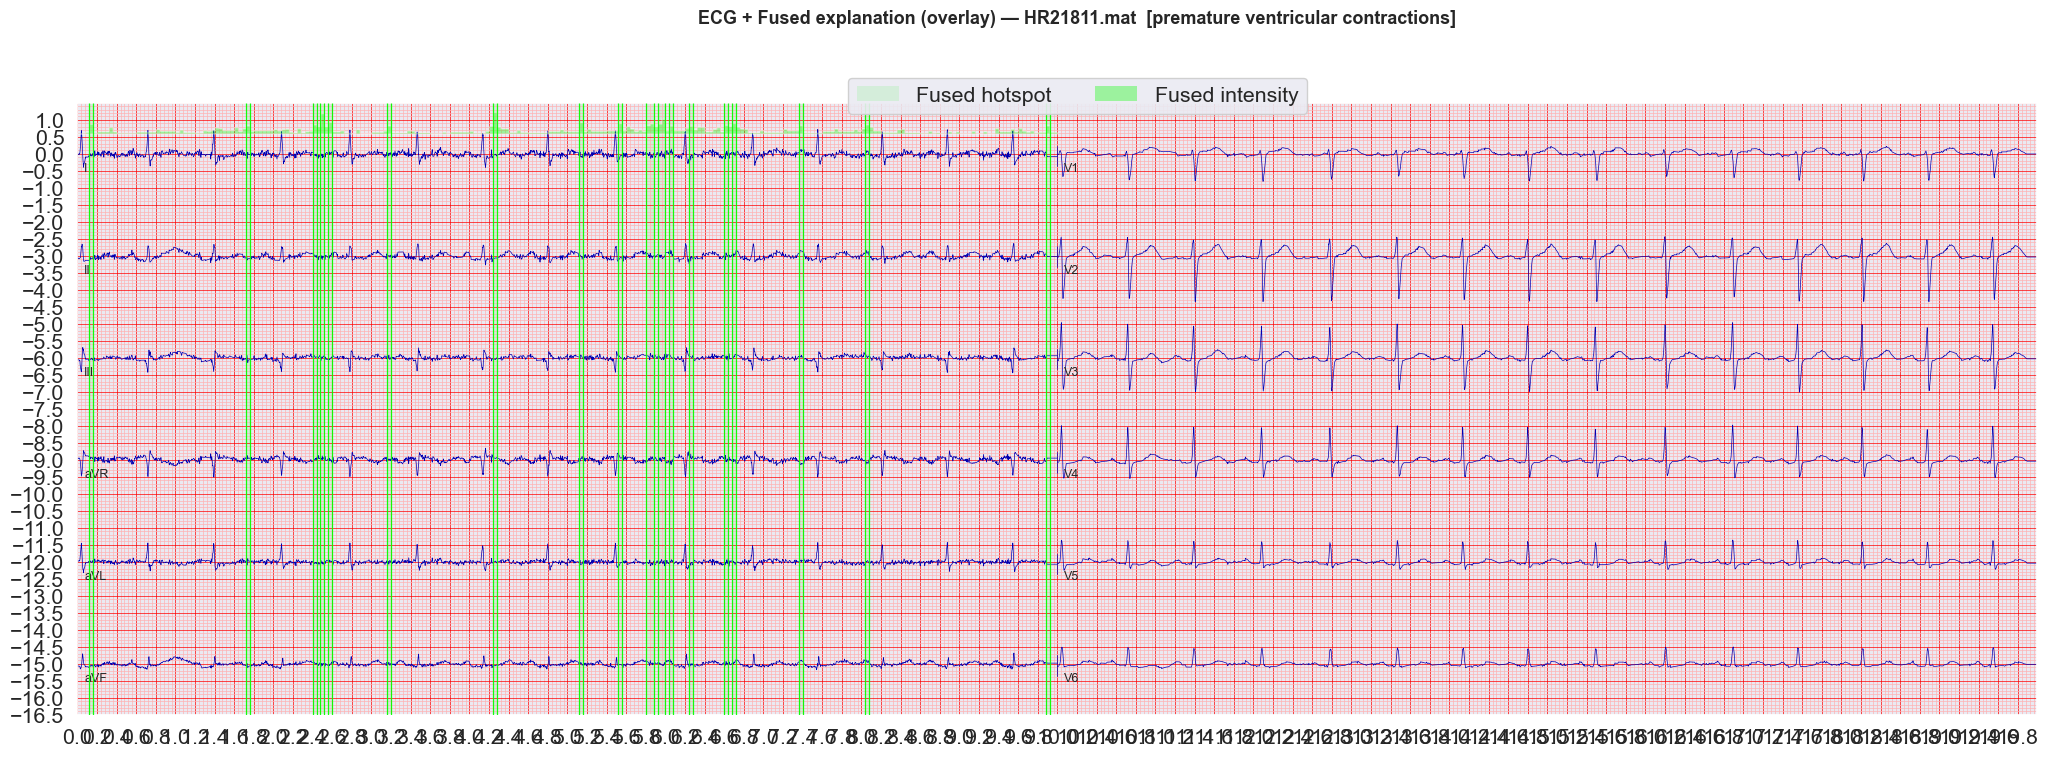

In [ ]:
df = pd.read_csv(CSV_PATH)
mat_path = df.loc[CHOSEN_ROW, "mat"] 
print(mat_path)

plot_ecg_with_fused(
    mat_path,
    payload,
    time_alpha=0.5,          # blend TS & LIME time equally (1.0 = TS-only)
    highlight_q=0.92,        # shade only the top ~8% hottest windows
    color="#09FF00",
    fill_alpha=0.10,         # make bands subtle; raise to 0.15–0.20 if you want bolder
    edge_alpha=0.95,
    edge_lw=0.9,
    show_strip=True,
    strip_pos="top",
    savepath="Q0948_fused_overlay_inside.png"
)

### Added Pruning

In [106]:
def run_predict_explain_with_pruning_and_summarize(csv_path: str,
                                                   row_idx: int,
                                                   lead_names=DEFAULT_LEADS,
                                                   fallback_baseline=True,
                                                   topn=5,
                                                   alpha=0.5,
                                                   lime_mode="positive",
                                                   verbose=True,
                                                   # --- pruning knobs ---
                                                   prune=True,
                                                   keep_quantile=0.85,     # keep top (1-q) by |coarse SHAP|
                                                   nsamples_coarse=64,     # cheap coarse pass
                                                   delta_tol=0.005,        # allowed abs prob shift after pruning
                                                   # --- NEW tightening knobs ---
                                                   topk_floor_frac=0.05,   # keep at least 5% if mask empty
                                                   topk_cap_frac=0.25,     # cap keep set at 25% for speed
                                                   min_keep=10,            # but keep at least this many
                                                   epsilon_scale=1e-8):    # epsilon gate factor
    """
    Reuses your globals & functions:
        model, pc, ecg_filenames, y,
        local_event, local_feat, lime_local, make_model_predict,
        FS, SECS, GROUP, UPSAMPLE_MODE, TS_NSAMPLES, LIME_EVENTS, LIME_FEAT_MS, LIME_EV_MS, LIME_BATCH
    """
    fused = None

    # 0) locate file
    df_idx = pd.read_csv(csv_path)
    fn_base = _basename(df_idx.iloc[row_idx]["mat"])
    basenames = np.array([_basename(f) for f in ecg_filenames], dtype=object)
    loc = np.where(basenames == fn_base)[0]
    if len(loc) == 0:
        raise ValueError(f"{fn_base} not found in ecg_filenames")
    idx_in_array = int(loc[0])
    full_mat_path = ecg_filenames[idx_in_array]

    # 1) preprocess & predict
    X_single = pc.generate_validation_data(ecg_filenames, y, np.array([idx_in_array]))[0]
    X_TF = _to_Tx12_strict(X_single[0])
    preds = model.predict(X_single, verbose=0)

    # labels
    if "snomed_classes" in globals():
        class_names = list(map(str, globals()["snomed_classes"]))
    else:
        class_names = [f"class_{i}" for i in range(preds.shape[1])]

    target_idx = _choose_target_index(preds)

    def _safe_nsamples(n_req: int, n_feat: int, min_ratio=1.15, min_add=4) -> int:
        """Ensure nsamples > n_features with a small margin."""
        return int(max(n_req, np.ceil(n_feat * min_ratio) + min_add))

    def _f(xx):
        p = model.predict(xx, batch_size=1024, verbose=0)
        return p[:, target_idx:target_idx+1]

    # 2) group tail
    K = min(int(SECS * FS), X_TF.shape[0])
    x_tail = X_TF[-K:, :]                         # (K, 12)
    x_tail_g, Kp = _group_tail_meanpool(x_tail, GROUP)

    # 3) explainers + tightened pruning
    def _run_with_baseline(baseline_arr):
        # --- coarse pass ---
        ns_coarse = _safe_nsamples(nsamples_coarse, Kp, min_ratio=1.05, min_add=3)
        event_dict_coarse = {"nsamples": ns_coarse, "rs": 0}
        ts_ev_df_coarse = local_event(_f, x_tail_g[None], event_dict_coarse, 0, "entity_id", baseline_arr, 0)
        s_coarse = _timeshap_event_series(ts_ev_df_coarse)
        if s_coarse is None:
            s_coarse = np.zeros(Kp, float)

        abs_s = np.abs(s_coarse)
        thr_q = np.quantile(abs_s, keep_quantile) if Kp > 0 else 0.0
        eps = epsilon_scale * abs_s.max() + 1e-12
        # epsilon gate ensures some separation
        keep_mask = abs_s >= max(thr_q, eps) if prune else np.ones(Kp, dtype=bool)

        # --- top-k fallback/cap ---
        k_floor = max(min_keep, int(np.ceil(topk_floor_frac * Kp)))
        k_cap   = max(k_floor, int(np.ceil(topk_cap_frac   * Kp)))
        if prune:
            if not np.any(keep_mask):
                # fallback: keep strongest floor
                idx_sorted = np.argsort(abs_s)
                keep_mask = np.zeros(Kp, bool)
                keep_mask[idx_sorted[-k_floor:]] = True
            # cap: avoid keeping too many (tighten for speed)
            if keep_mask.sum() > k_cap:
                idx_sorted = np.argsort(abs_s)
                new_mask = np.zeros(Kp, bool)
                new_mask[idx_sorted[-k_cap:]] = True
                keep_mask = new_mask

        # --- fidelity check (replace pruned events by their own baseline rows) ---
        p_full = float(_f(x_tail_g[None])[0, 0])
        x_drop = x_tail_g.copy()
        # use per-event baseline row, not a single row
        x_drop[~keep_mask] = baseline_arr[0, ~keep_mask, :]
        p_drop = float(_f(x_drop[None])[0, 0])
        delta = abs(p_full - p_drop)

        if prune and (delta > delta_tol):
            # relax pruning by lowering threshold 10% (e.g., 0.85 -> 0.75)
            thr2 = np.quantile(abs_s, max(0.75, keep_quantile - 0.10))
            relax_mask = abs_s >= max(thr2, eps)
            # ensure not exceeding cap too much; allow up to 35% as a relaxed cap
            k_relax_cap = max(k_cap, int(np.ceil(0.35 * Kp)))
            if relax_mask.sum() > k_relax_cap:
                idx_sorted = np.argsort(abs_s)
                new_mask = np.zeros(Kp, bool)
                new_mask[idx_sorted[-k_relax_cap:]] = True
                relax_mask = new_mask
            keep_mask = relax_mask
            x_drop = x_tail_g.copy()
            x_drop[~keep_mask] = baseline_arr[0, ~keep_mask, :]
            p_drop = float(_f(x_drop[None])[0, 0])
            delta = abs(p_full - p_drop)

        # --- full passes ---
        ns_full_ev = _safe_nsamples(TS_NSAMPLES, Kp,  min_ratio=1.10, min_add=5)
        ns_full_ft = _safe_nsamples(TS_NSAMPLES, 12,  min_ratio=1.10, min_add=5)
        event_dict_full   = {"nsamples": ns_full_ev, "rs": 0}
        feature_dict_full = {"nsamples": ns_full_ft, "rs": 0}

        ts_ev_df_full = local_event(_f, x_tail_g[None], event_dict_full, 0, "entity_id", baseline_arr, 0)
        s_full = _timeshap_event_series(ts_ev_df_full)
        if s_full is None:
            s_full = np.zeros(Kp, float)
        s_full_pruned = s_full * keep_mask.astype(float)

        # feature-level
        ts_ft_df_g = local_feat(_f, x_tail_g[None], feature_dict_full, 0, "entity_id", baseline_arr, 0)
        ts_ft_named = _map_ts_features_to_leads(ts_ft_df_g, lead_names)
        val_col = _pick_val_col(ts_ft_named)
        ts_agg = _agg_lead_pos_neg_abs(ts_ft_named, val_col, lead_names)

        # LIME (on pruned input)
        x_for_lime = x_tail_g.copy()
        if prune:
            x_for_lime[~keep_mask] = baseline_arr[0, ~keep_mask, :]

        res_lime = lime_local(
            model_predict=make_model_predict(model),
            x=x_for_lime,
            class_index=target_idx,
            n_events=min(LIME_EVENTS, int(keep_mask.sum()) if prune else Kp),
            n_feature_masks=LIME_FEAT_MS, n_event_masks=LIME_EV_MS,
            batch_size=LIME_BATCH,
            removal=("mean" if np.all(baseline_arr != 0) else "zero"),
            event_mode="fixed"
        )
        lime_event_slices_g = np.asarray(res_lime.get("event_slices"), int)
        lime_event_w_g      = np.asarray(res_lime.get("event_importance"), float).ravel()

        lime_per_time_g = np.zeros(Kp, float)
        if lime_event_slices_g is not None and lime_event_slices_g.size > 0:
            for (s, e), w in zip(lime_event_slices_g, lime_event_w_g):
                if e > s:
                    lime_per_time_g[s:e] += float(w) / float(e - s)

        return {
            "ts_per_time_g_raw": s_full,             # before pruning
            "ts_per_time_g": s_full_pruned,          # after pruning
            "keep_mask": keep_mask,
            "p_full": p_full, "p_drop": p_drop, "delta": delta,
            "ts_feat_df": ts_ft_named,
            "ts_lead_agg": ts_agg,
            "res_lime": res_lime,
            "lime_event_slices_g": lime_event_slices_g,
            "lime_event_w_g": lime_event_w_g,
            "lime_per_time_g": lime_per_time_g
        }

    # mean baseline first (shape: (1, Kp, 12))
    baseline_mean = np.broadcast_to(x_tail_g[None].mean(axis=1, keepdims=True), (1, Kp, 12)).astype(np.float32)
    out = _run_with_baseline(baseline_mean)

    # fallback baseline if degenerate
    if fallback_baseline and float(out["ts_lead_agg"]["abs"].sum()) == 0.0:
        baseline_zero = np.zeros((1, Kp, 12), np.float32)
        out = _run_with_baseline(baseline_zero)
        baseline_used = "zero"
    else:
        baseline_used = "mean"

    # 4) upsample for overlay
    ts_series_full   = _upsample_series(out["ts_per_time_g"],   K, GROUP, UPSAMPLE_MODE)
    lime_series_full = _upsample_series(out["lime_per_time_g"], K, GROUP, UPSAMPLE_MODE)

    # 5) summary + fusion
    top_idx = int(np.argmax(preds))
    top_prob = float(np.ravel(preds)[top_idx])
    top_label = class_names[top_idx] if 0 <= top_idx < len(class_names) else f"idx_{top_idx}"

    ts_lead = out["ts_lead_agg"]
    show_pos = ts_lead["pos"].sum() > 0
    ts_rank_series = ts_lead["pos"] if show_pos else ts_lead["abs"]
    ts_kind = "positive" if show_pos else "absolute"

    lime_per_lead = _lime_per_lead_series(out["res_lime"], lead_names, mode=lime_mode)
    if lime_per_lead is not None:
        fused = _fuse_ts_lime_per_lead(ts_lead["pos"], lime_per_lead, alpha=alpha)

    if verbose:
        print("=== Single-ECG Explanation ===")
        print(f"File: {fn_base}")
        print(f"Predicted top class: {top_label}  (p={top_prob:.3f})")
        print(f"TimeSHAP baseline used: {baseline_used}")
        if prune:
            kept = int(out["keep_mask"].sum())
            print(f"Pruning: kept {kept}/{Kp} events ({100.0*kept/Kp:.1f}%), "
                  f"Δprob after pruning={out['delta']:.4f} (tol={delta_tol})")
        print("\nTimeSHAP per-lead contributions:")
        print(f"  • Using {ts_kind} contributions to rank leads")
        for lead, val in ts_rank_series.sort_values(ascending=False).head(topn).items():
            neg = ts_lead.loc[lead, "neg"]
            pos = ts_lead.loc[lead, "pos"]
            print(f"  - {lead:<3}  pos={pos:.6f}  neg={neg:.6f}  abs={ts_lead.loc[lead,'abs']:.6f}")

        lime_time_pos = float(np.clip(out["lime_per_time_g"], 0, None).sum())
        lime_time_neg = float(np.clip(out["lime_per_time_g"], None, 0).sum())
        print("\nLIME (time-wise) mass:")
        print(f"  - positive mass (grouped time): {lime_time_pos:.6f}")
        print(f"  - negative mass (grouped time): {lime_time_neg:.6f}")

        if lime_per_lead is not None:
            print("\nLIME per-lead (positive):")
            for lead, val in lime_per_lead.sort_values(ascending=False).head(topn).items():
                print(f"  - {lead:<3}  {val:.6f}")
            if fused is not None:
                print(f"\nFused per-lead (alpha={alpha:.2f} → TS weight):")
                for lead, val in fused.sort_values(ascending=False).head(topn).items():
                    print(f"  - {lead:<3}  {val:.6f}")
        else:
            print("\n(Per-lead LIME not available — add 'feature_importance' (+ optional 'feature_names') to lime_local() result.)")

        print("\nSummary (human-readable):")
        if show_pos:
            top_leads = ", ".join([f"{k}" for k in ts_lead['pos'].sort_values(ascending=False).head(topn).index])
            print(f"Model’s confidence in '{top_label}' is primarily supported by activity in leads: {top_leads}.")
        else:
            top_leads = ", ".join([f"{k}" for k in ts_lead['abs'].sort_values(ascending=False).head(topn).index])
            print(f"Model focused most strongly (by absolute contribution) on leads: {top_leads}, but the evidence skewed negative.")

    return {
        "file": fn_base,
        "mat_path": full_mat_path,
        "target_label": top_label,
        "X_TF": X_TF,
        "FS": FS,
        "K": K,
        "t0_sec": (X_TF.shape[0]-K)/FS,
        "ts_series_full": ts_series_full,        # pruned
        "lime_series_full": lime_series_full,
        "ts_lead_pos": ts_lead["pos"],
        "ts_lead_abs": ts_lead["abs"],
        "lead_names": lead_names,
        "fused": fused,
        "pruned": {
            "keep_mask": out["keep_mask"],
            "kept": int(out["keep_mask"].sum()),
            "total": int(Kp),
            "delta": float(out["delta"]),
            "keep_quantile": float(keep_quantile),
            "topk_floor_frac": float(topk_floor_frac),
            "topk_cap_frac": float(topk_cap_frac),
            "ts_per_time_g_raw": out["ts_per_time_g_raw"],
        }
    }


In [111]:
# ---------- Example usage ----------
CHOSEN_ROW = 919
CSV_PATH   = CSV_CACHE

payload = run_predict_explain_with_pruning_and_summarize(
    CSV_PATH,
    row_idx=CHOSEN_ROW,
    alpha=0.5,
    lime_mode="positive",
    verbose=True,
    prune=True,            # ← enable pruning
    keep_quantile=0.98,    # keep top ~15% events by |coarse SHAP|
    nsamples_coarse=64,    # cheap screen
    delta_tol=0.005        # ≤0.5% absolute prob shift allowed
)


8/8 [==============================] - 0s 47ms/step
=== Single-ECG Explanation ===
File: Q0948.mat
Predicted top class: right bundle branch block  (p=0.769)
TimeSHAP baseline used: mean
Pruning: kept 30/250 events (12.0%), Δprob after pruning=0.0505 (tol=0.005)

TimeSHAP per-lead contributions:
  • Using positive contributions to rank leads
  - aVL  pos=0.010968  neg=0.000000  abs=0.010968
  - aVR  pos=0.009334  neg=0.000000  abs=0.009334
  - aVF  pos=0.009030  neg=0.000000  abs=0.009030
  - I    pos=0.007542  neg=0.000000  abs=0.007542
  - V2   pos=0.006988  neg=0.000000  abs=0.006988

LIME (time-wise) mass:
  - positive mass (grouped time): 0.080065
  - negative mass (grouped time): -0.000388

LIME per-lead (positive):
  - aVF  0.008482
  - V2   0.005901
  - V5   0.005151
  - II   0.004441
  - V4   0.003698

Fused per-lead (alpha=0.50 → TS weight):
  - aVF  0.176152
  - V2   0.127160
  - V5   0.097935
  - II   0.095363
  - aVL  0.091038

Summary (human-readable):
Model’s confidence i

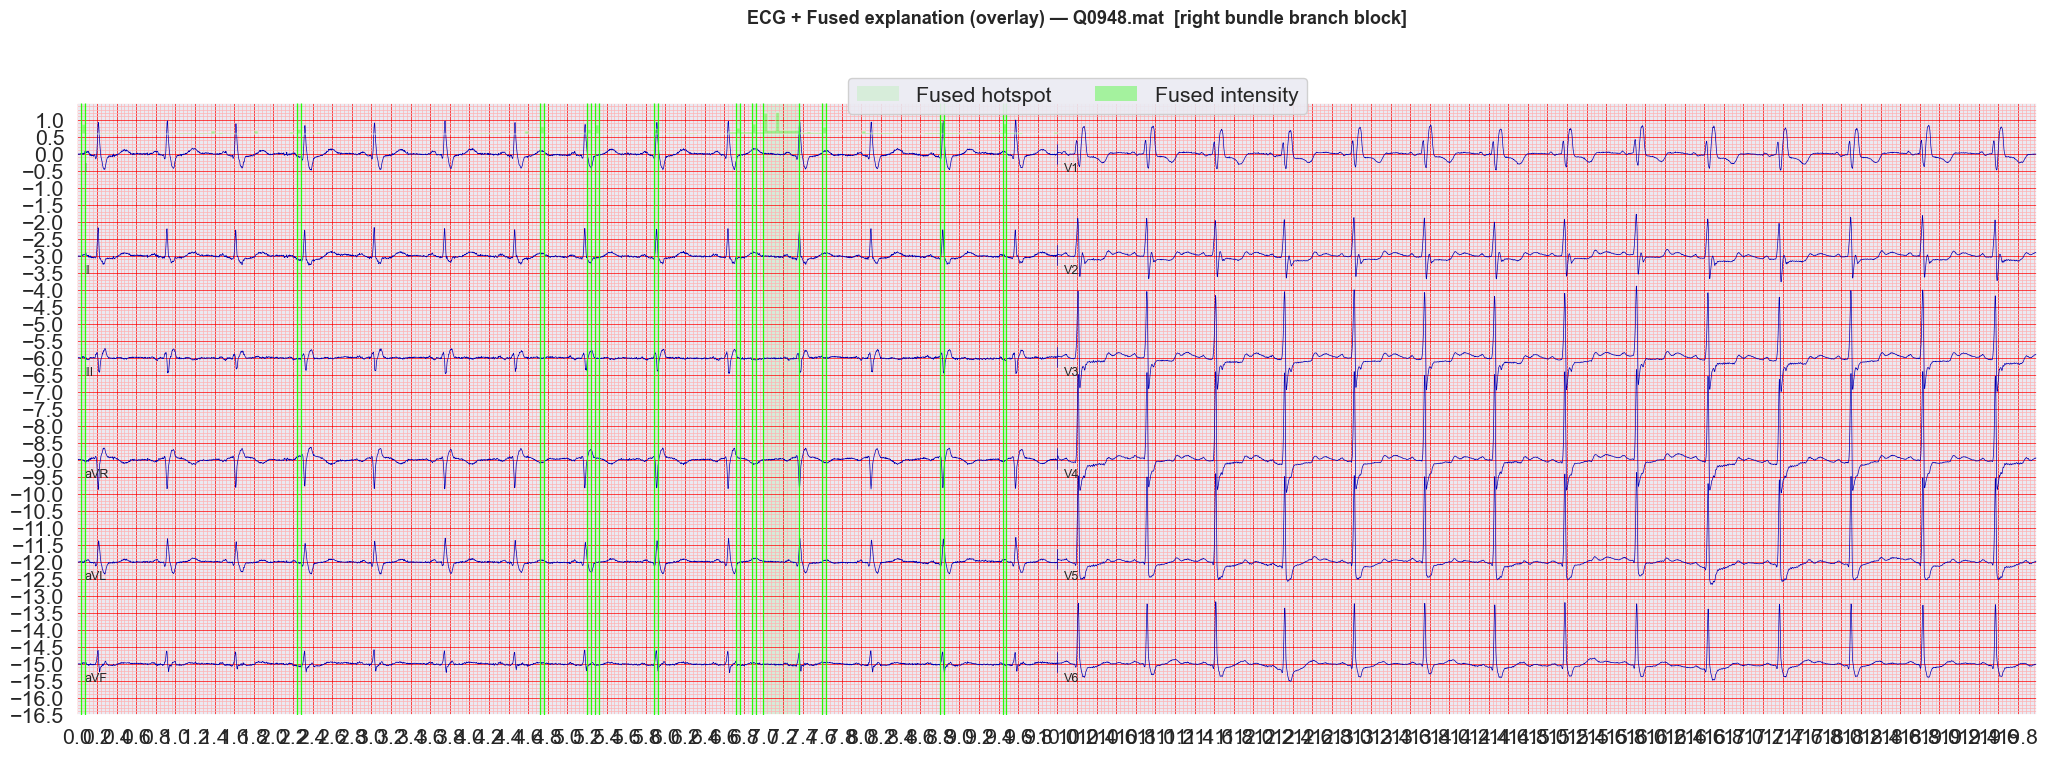

In [112]:
df = pd.read_csv(CSV_PATH)
mat_path = df.loc[CHOSEN_ROW, "mat"] 

plot_ecg_with_fused(
    mat_path,
    payload,
    time_alpha=0.5,          # blend TS & LIME time equally (1.0 = TS-only)
    highlight_q=0.92,        # shade only the top ~8% hottest windows
    color="#1EFF00FF",
    fill_alpha=0.10,         # make bands subtle; raise to 0.15–0.20 if you want bolder
    edge_alpha=0.95,
    edge_lw=0.9,
    show_strip=True,
    strip_pos="top",
    savepath="Q0948_fused_overlay_inside.png"
)

# TBC Add from here

If can plug into an LLM, and make the summary more human-readable.

timeshap pruning

Explainability Evaluation - example: consistency (Attribution consistency, attribution accuracy)

Find the place where the problematic bit is logged on the ecg